In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Загрузка датасета Human Activity Recognition
# Целевая переменная: 6 типов активности (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
human_activity = fetch_openml('har', version=1)

X = pd.DataFrame(human_activity.data, columns=human_activity.feature_names)
y = pd.Series(human_activity.target)

df = pd.concat([X, y.rename('activity')], axis=1)

print(f"Размер данных: {df.shape}")
print("\nПервые 5 строк данных:")
print(df.head())

print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\nКоличество уникальных значений в целевой переменной:")
print(df['activity'].value_counts())

Размер данных: (10299, 562)

Первые 5 строк данных:
         V1        V2        V3        V4        V5        V6        V7  \
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   

         V8        V9       V10  ...      V553      V554      V555      V556  \
0 -0.983185 -0.923527 -0.934724  ... -0.298676 -0.710304 -0.112754  0.030400   
1 -0.974914 -0.957686 -0.943068  ... -0.595051 -0.861499  0.053477 -0.007435   
2 -0.963668 -0.977469 -0.938692  ... -0.390748 -0.760104 -0.118559  0.177899   
3 -0.982750 -0.989303 -0.938692  ... -0.117290 -0.482845 -0.036788 -0.012892   
4 -0.979672 -0.990441 -0.942469  ... -0.351471 -0.699205  0.123320  0.122542   

       V557     

Базовые статистики числовых признаков:
                 V1            V2            V3            V4            V5  \
count  10299.000000  10299.000000  10299.000000  10299.000000  10299.000000   
mean       0.274347     -0.017743     -0.108925     -0.607784     -0.510191   
std        0.067628      0.037128      0.053033      0.438694      0.500240   
min       -1.000000     -1.000000     -1.000000     -1.000000     -1.000000   
25%        0.262624     -0.024903     -0.121019     -0.992360     -0.976990   
50%        0.277174     -0.017162     -0.108596     -0.943030     -0.835032   
75%        0.288354     -0.010625     -0.097589     -0.250293     -0.057336   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

                 V6            V7            V8            V9           V10  \
count  10299.000000  10299.000000  10299.000000  10299.000000  10299.000000   
mean      -0.613064     -0.633593     -0.525697     -0.614989     -0.466732   
std        0

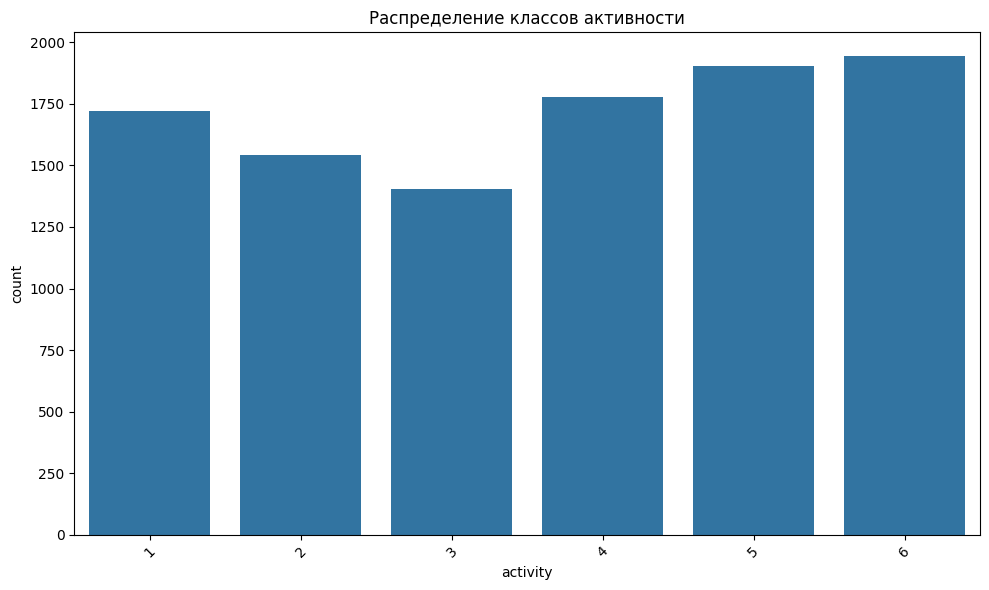

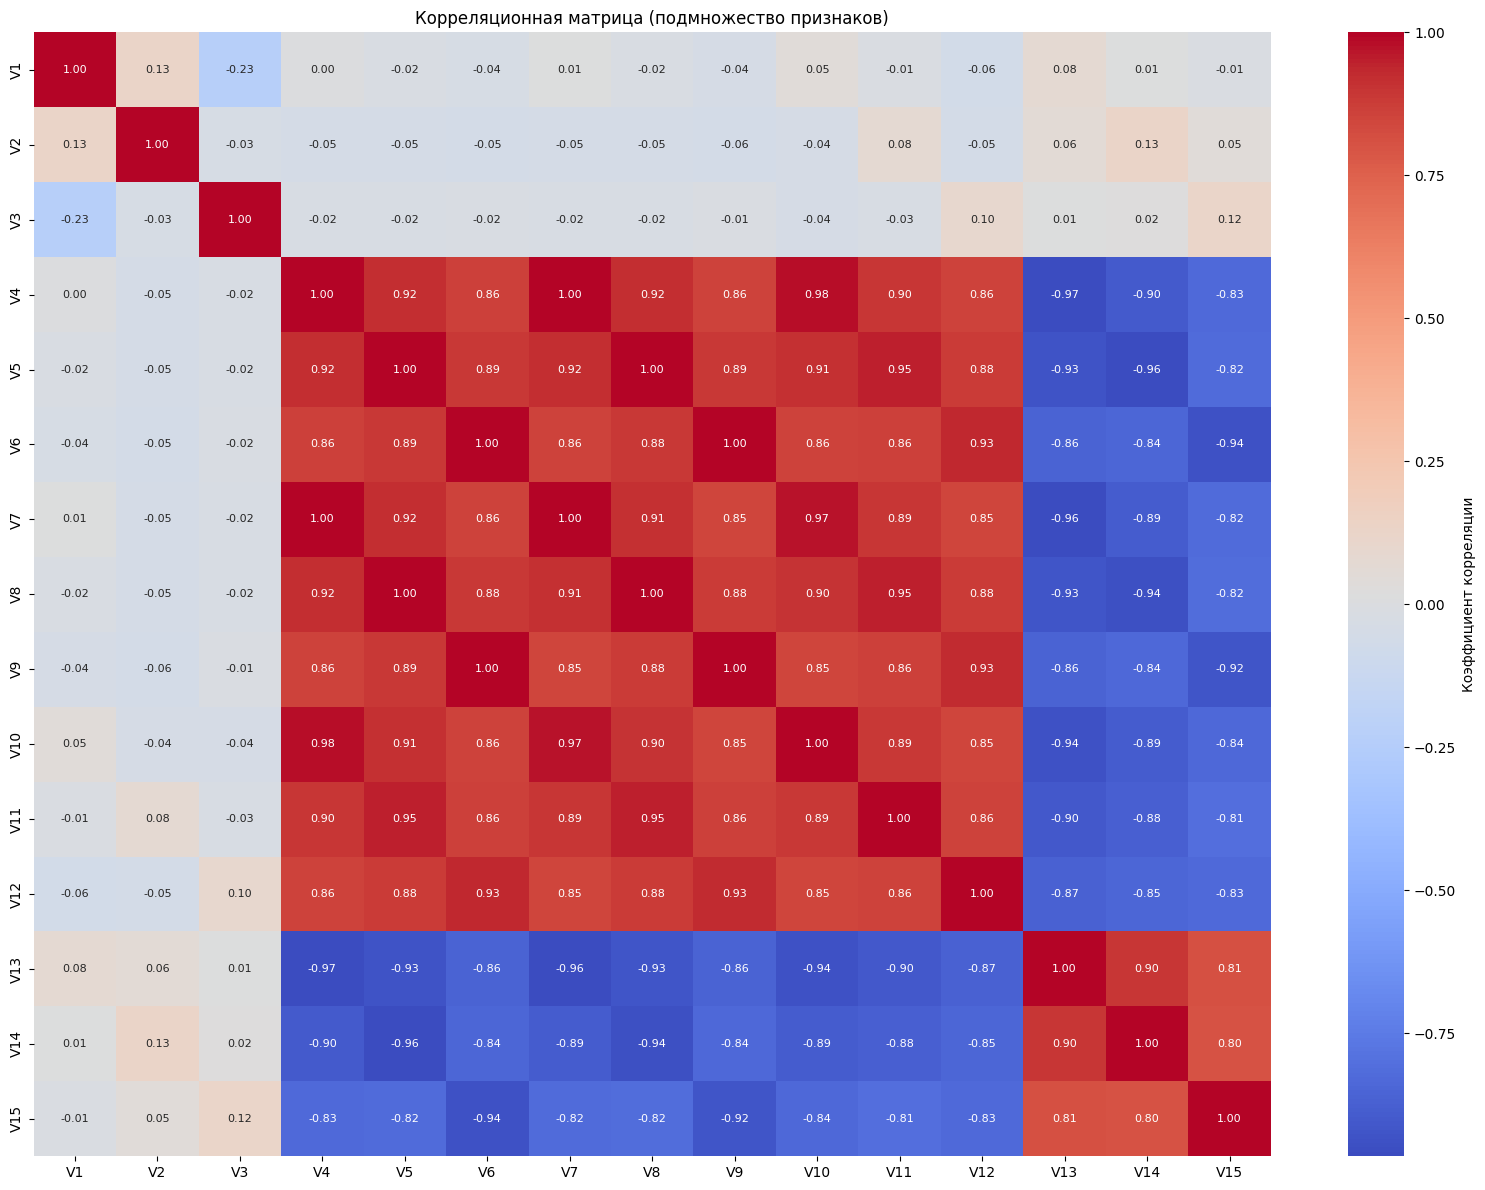


Данные успешно предобработаны и разделены на обучающую и тестовую выборки.
Размер обучающей выборки: (8239, 561)
Размер тестовой выборки: (2060, 561)


In [25]:
# Импорт библиотек для визуализации и предобработки
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Отображение базовых статистик
print("Базовые статистики числовых признаков:")
print(df.describe())

# Проверка на пропущенные значения
missing_values = df.isnull().sum().sum()
print(f"\nКоличество пропущенных значений в датасете: {missing_values}")

# Визуализация распределения целевой переменной
plt.figure(figsize=(10, 6))
sns.countplot(x='activity', data=df)
plt.title('Распределение классов активности')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Визуализация корреляции признаков
# Возьмем первые 15 признаков для корреляционной матрицы
plt.figure(figsize=(16, 12))
subset_features = df.columns[:15].tolist() + ['activity']
correlation_matrix = df[subset_features].corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            annot_kws={'size': 8}, cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляционная матрица (подмножество признаков)')
plt.tight_layout()
plt.show()

# Преобразование целевой переменной в числовой формат
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['activity_encoded'] = le.fit_transform(df['activity'])
y_encoded = df['activity_encoded']

# Разделение данных на обучающую и тестовую выборки
X = df.drop(['activity', 'activity_encoded'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nДанные успешно предобработаны и разделены на обучающую и тестовую выборки.")
print(f"Размер обучающей выборки: {X_train_scaled.shape}")
print(f"Размер тестовой выборки: {X_test_scaled.shape}")

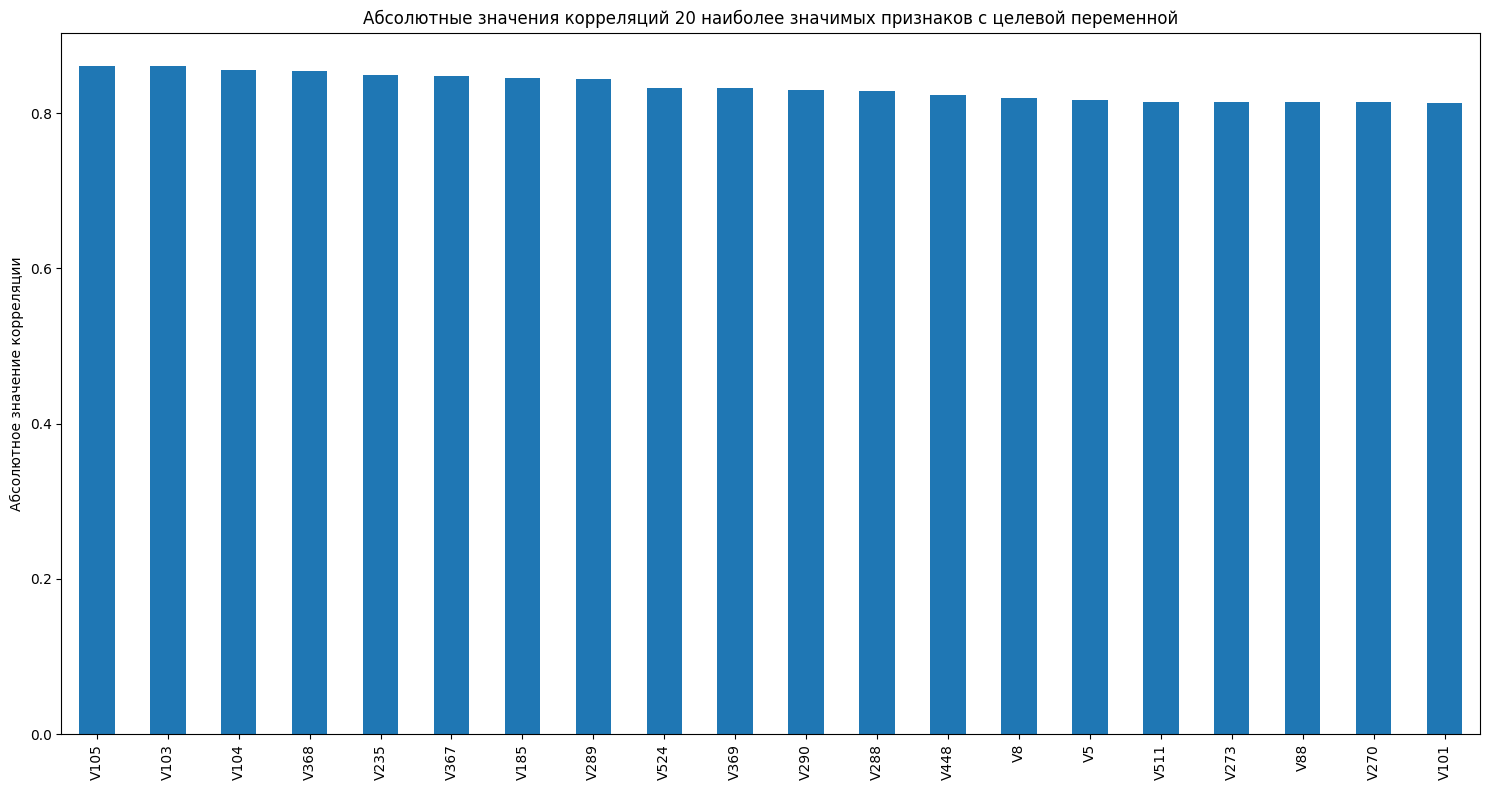


Найдено 16061 пар признаков с корреляцией > 0.85:
V4 и V5: корреляция = 0.923
V4 и V6: корреляция = 0.862
V4 и V7: корреляция = 0.999
V4 и V8: корреляция = 0.917
V4 и V9: корреляция = 0.857
V4 и V10: корреляция = 0.981
V4 и V11: корреляция = 0.899
V4 и V12: корреляция = 0.857
V4 и V13: корреляция = 0.966
V4 и V14: корреляция = 0.896

Количество признаков для удаления из-за высокой корреляции: 398
Признаки для удаления: ['V226', 'V517', 'V528', 'V518', 'V413', 'V442', 'V124', 'V500', 'V395', 'V477']

Количество признаков с корреляцией > 0.1 с целевой переменной: 495
Количество признаков после корреляционного отбора: 118


In [27]:
# Импорт библиотек для отбора признаков
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# Добавление целевой переменной для корреляционного анализа
X_train_df['target'] = y_train.values

correlations = X_train_df.corr()['target'].sort_values(ascending=False)
correlations = correlations.drop('target')

# Визуализация корреляций
plt.figure(figsize=(15, 8))
correlations.abs().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Абсолютные значения корреляций 20 наиболее значимых признаков с целевой переменной')
plt.ylabel('Абсолютное значение корреляции')
plt.tight_layout()
plt.show()

# Анализ корреляций между признаками для выявления мультиколлинеарности
# Выберем признаки с корреляцией > 0.85
corr_matrix = X_train_df.drop('target', axis=1).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Найдем пары признаков с высокой корреляцией
high_corr_pairs = []
for row in range(len(upper_tri.columns)):
    for col in range(row+1, len(upper_tri.columns)):
        if upper_tri.iloc[row, col] > 0.85:
            high_corr_pairs.append((upper_tri.columns[row], upper_tri.columns[col], upper_tri.iloc[row, col]))

print(f"\nНайдено {len(high_corr_pairs)} пар признаков с корреляцией > 0.85:")
for pair in high_corr_pairs[:10]:
    print(f"{pair[0]} и {pair[1]}: корреляция = {pair[2]:.3f}")

# Удалим один из признаков из каждой высококоррелирующей пары
high_corr_features = set()
for pair in high_corr_pairs:
    # Оставим признак с большей корреляцией с целевой переменной
    corr1 = abs(correlations[pair[0]])
    corr2 = abs(correlations[pair[1]])
    if corr1 < corr2:
        high_corr_features.add(pair[0])
    else:
        high_corr_features.add(pair[1])

print(f"\nКоличество признаков для удаления из-за высокой корреляции: {len(high_corr_features)}")
print("Признаки для удаления:", list(high_corr_features)[:10])

# Применение порога корреляции с целевой переменной
# Оставим признаки с корреляцией > 0.1 по абсолютному значению
threshold = 0.1
significant_features = correlations[abs(correlations) > threshold].index
print(f"\nКоличество признаков с корреляцией > {threshold} с целевой переменной: {len(significant_features)}")

# Финальный набор признаков после корреляционного отбора
final_corr_features = [f for f in significant_features if f not in high_corr_features]
print(f"Количество признаков после корреляционного отбора: {len(final_corr_features)}")

Топ-10 признаков по f_classif:
    feature  f_classif_score  f_classif_rank  mi_score  mi_rank
366    V367     40769.651918               1  0.763714      101
40      V41     37841.992413               2  0.643930      344
52      V53     36359.769637               3  0.780169       79
49      V50     33976.440212               4  0.704414      249
56      V57     32810.616400               5  0.645906      342
367    V368     29333.926401               6  0.745259      144
234    V235     25953.422000               7  0.788710       64
523    V524     25941.396871               8  0.762618      102
287    V288     25793.466287               9  0.813021       38
102    V103     25002.780507              10  0.742807      149

Топ-10 признаков по mutual_info_classif:
    feature  f_classif_score  f_classif_rank  mi_score  mi_rank
9       V10     22191.306087              11  0.971670        1
89      V90      9268.867510              87  0.898816        2
302    V303      5550.816151   

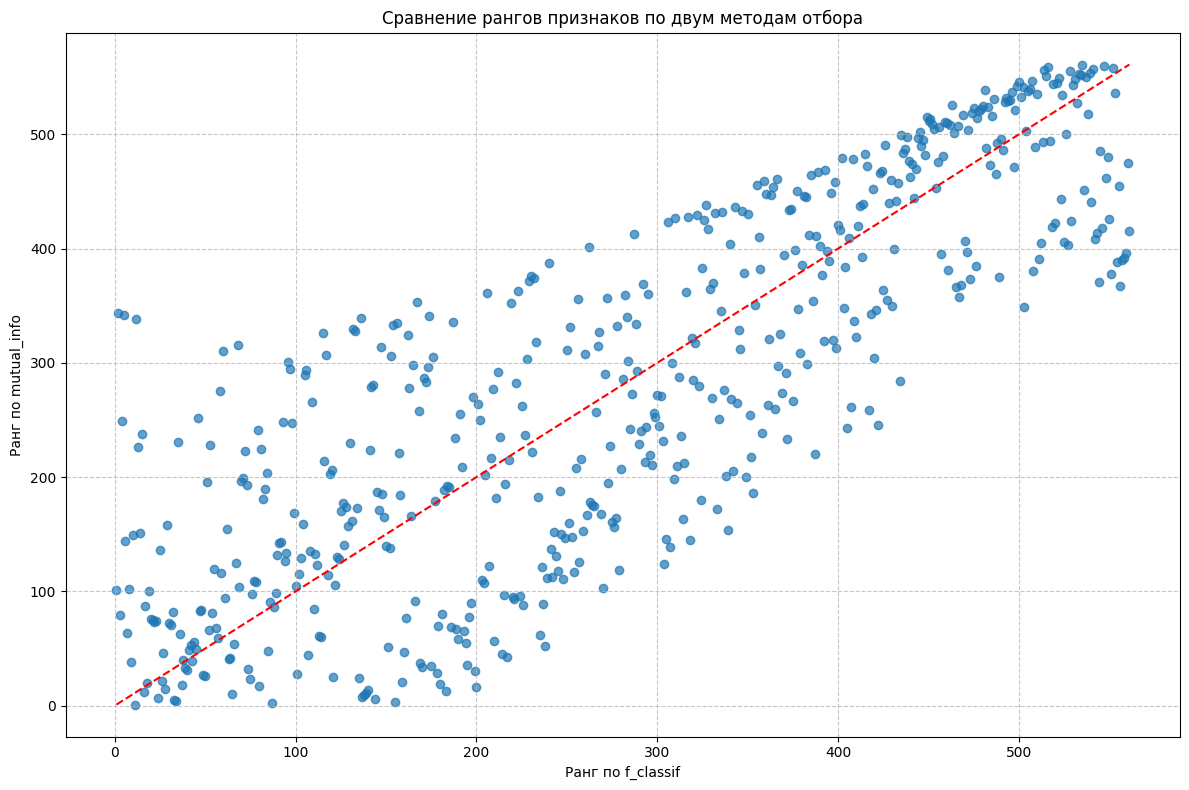


10 наиболее информативных признаков по f_classif:
['x40' 'x49' 'x52' 'x56' 'x102' 'x234' 'x287' 'x366' 'x367' 'x523']

Проверка устойчивости признаков при варьировании случайного состояния...
Random state 0, отобранные признаки: ['V41', 'V50', 'V53', 'V57', 'V103', 'V235', 'V288', 'V367', 'V368', 'V524']
Random state 1, отобранные признаки: ['V41', 'V50', 'V53', 'V57', 'V103', 'V235', 'V288', 'V367', 'V368', 'V524']
Random state 2, отобранные признаки: ['V41', 'V50', 'V53', 'V57', 'V103', 'V235', 'V288', 'V367', 'V368', 'V524']

Устойчивые признаки (присутствуют во всех выборках): {'V50', 'V368', 'V367', 'V524', 'V103', 'V235', 'V57', 'V53', 'V41', 'V288'}
Количество устойчивых признаков: 10


In [28]:
from sklearn.feature_selection import mutual_info_classif

# Применение f_classif (ANOVA F-value)
selector_f = SelectKBest(f_classif, k=10)
selector_f.fit(X_train_scaled, y_train)
scores_f = selector_f.scores_

# Применение mutual_info_classif
selector_mi = SelectKBest(mutual_info_classif, k=10)
selector_mi.fit(X_train_scaled, y_train)
scores_mi = selector_mi.scores_

# Создание DataFrame для сравнения результатов
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_classif_score': scores_f,
    'f_classif_rank': np.argsort(np.argsort(-scores_f)) + 1,  # Ранжирование
    'mi_score': scores_mi,
    'mi_rank': np.argsort(np.argsort(-scores_mi)) + 1  # Ранжирование
})

# Сортировка по f_classif_score
feature_scores = feature_scores.sort_values('f_classif_score', ascending=False)

print("Топ-10 признаков по f_classif:")
print(feature_scores.head(10))

print("\nТоп-10 признаков по mutual_info_classif:")
print(feature_scores.sort_values('mi_score', ascending=False).head(10))

# Сравнение рангов признаков по двум методам
plt.figure(figsize=(12, 8))
plt.scatter(feature_scores['f_classif_rank'], feature_scores['mi_rank'], alpha=0.7)
plt.xlabel('Ранг по f_classif')
plt.ylabel('Ранг по mutual_info')
plt.title('Сравнение рангов признаков по двум методам отбора')
plt.plot([1, len(X.columns)], [1, len(X.columns)], 'r--')  # Диагональ для сравнения
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Выбор 10 наиболее информативных признаков по f_classif
top_10_f = selector_f.get_feature_names_out()
print("\n10 наиболее информативных признаков по f_classif:")
print(top_10_f)

# Проверка устойчивости признаков при варьировании случайного состояния
print("\nПроверка устойчивости признаков при варьировании случайного состояния...")
import random
stable_features = set()
for state in range(3):  # Протестируем 3 разных random_state
    X_train_sample, _, y_train_sample, _ = train_test_split(X, y_encoded, test_size=0.2, random_state=state)
    scaler = StandardScaler()
    X_train_sample_scaled = scaler.fit_transform(X_train_sample)
    
    selector = SelectKBest(f_classif, k=10)
    selector.fit(X_train_sample_scaled, y_train_sample)
    features = X.columns[selector.get_support()]
    
    if state == 0:
        stable_features = set(features)
    else:
        stable_features = stable_features.intersection(set(features))
    
    print(f"Random state {state}, отобранные признаки: {features.tolist()}")

print(f"\nУстойчивые признаки (присутствуют во всех выборках): {stable_features}")
print(f"Количество устойчивых признаков: {len(stable_features)}")

K=5, количество отобранных признаков: 5
Топ-5 признаков: ['V41', 'V50', 'V53', 'V57', 'V367']
K=10, количество отобранных признаков: 10
Топ-5 признаков: ['V41', 'V50', 'V53', 'V57', 'V103']
K=20, количество отобранных признаков: 20
Топ-5 признаков: ['V4', 'V10', 'V16', 'V41', 'V50']
K=50, количество отобранных признаков: 50
Топ-5 признаков: ['V4', 'V7', 'V10', 'V16', 'V41']
K=100, количество отобранных признаков: 100
Топ-5 признаков: ['V4', 'V5', 'V7', 'V8', 'V10']
K=200, количество отобранных признаков: 200
Топ-5 признаков: ['V4', 'V5', 'V6', 'V7', 'V8']
K=400, количество отобранных признаков: 400
Топ-5 признаков: ['V4', 'V5', 'V6', 'V7', 'V8']

Анализ перекрытия признаков при разных значениях K:
Перекрытие между K=5 и K=10: 5 общих признаков, коэффициент Жаккара: 0.500
Перекрытие между K=10 и K=20: 10 общих признаков, коэффициент Жаккара: 0.500
Перекрытие между K=20 и K=50: 20 общих признаков, коэффициент Жаккара: 0.400
Перекрытие между K=50 и K=100: 50 общих признаков, коэффициент Ж

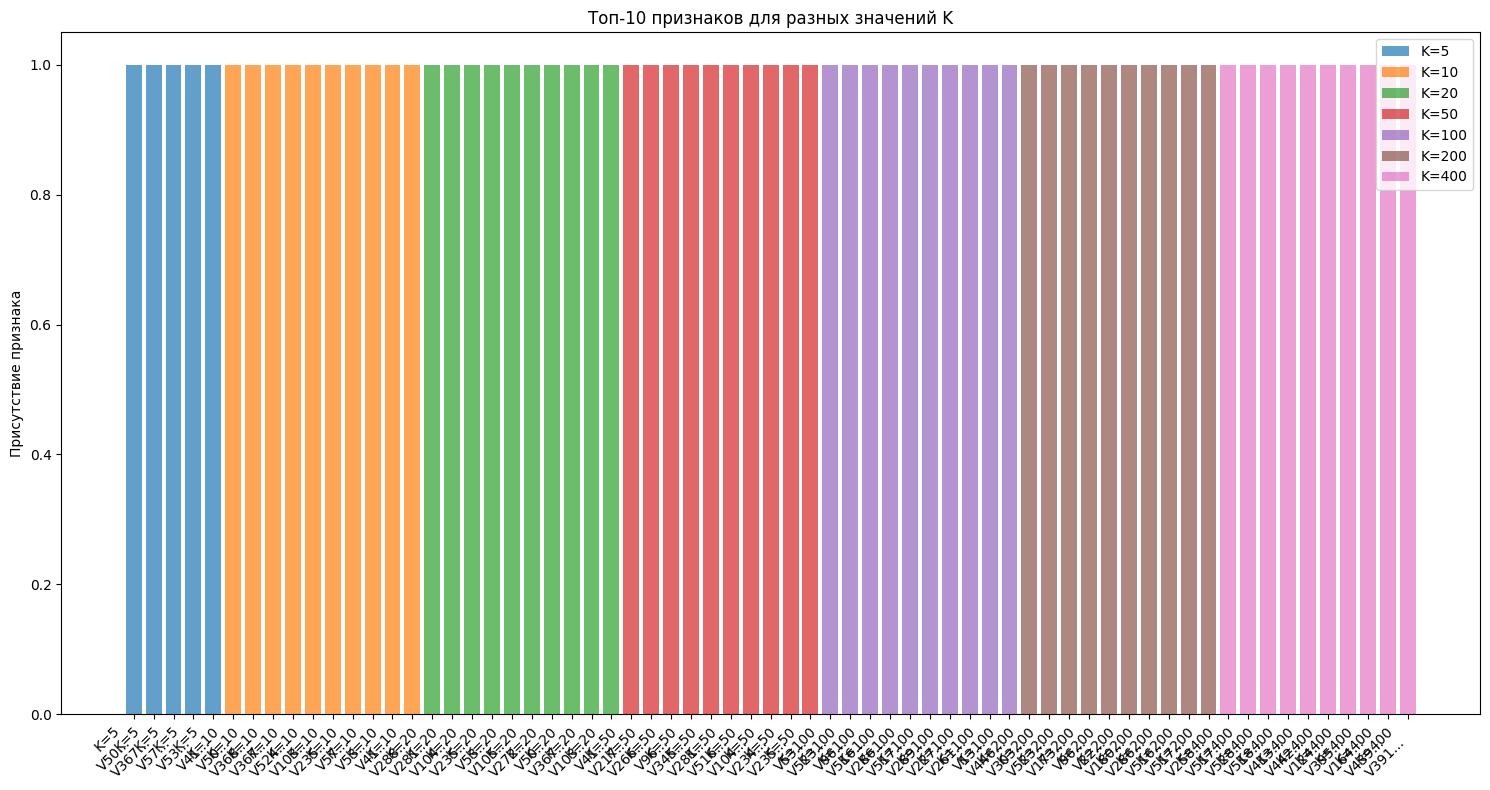

In [29]:
# Создание массива для хранения результатов
k_values = [5, 10, 20, 50, 100, 200, 400]
feature_sets = {}
top_features_by_k = []

# Отбор признаков для разных значений K
for k in k_values:
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train_scaled, y_train)
    selected_features = X.columns[selector.get_support()]
    feature_sets[k] = set(selected_features)
    top_features_by_k.append(selected_features[:10])  # Топ-10 для каждого K
    
    print(f"K={k}, количество отобранных признаков: {len(selected_features)}")
    print(f"Топ-5 признаков: {selected_features[:5].tolist()}")

# Анализ изменений в составе признаков при увеличении K
print("\nАнализ перекрытия признаков при разных значениях K:")
for i in range(len(k_values)-1):
    k1 = k_values[i]
    k2 = k_values[i+1]
    overlap = feature_sets[k1].intersection(feature_sets[k2])
    jaccard = len(overlap) / len(feature_sets[k1].union(feature_sets[k2]))
    print(f"Перекрытие между K={k1} и K={k2}: {len(overlap)} общих признаков, коэффициент Жаккара: {jaccard:.3f}")

# Визуализация состава признаков для разных K
plt.figure(figsize=(15, 8))
for i, k in enumerate(k_values):
    features = list(feature_sets[k])[:10]  # Берем топ-10 для визуализации
    plt.bar([f"K={k}\n{feature[:10]}..." for feature in features], 
            [1] * len(features), 
            label=f'K={k}', alpha=0.7)

plt.title('Топ-10 признаков для разных значений K')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Присутствие признака')
plt.legend()
plt.tight_layout()
plt.show()

Обучение модели на полном наборе признаков...
Время обучения на полном наборе: 1.99 секунд
Обучение модели на отобранных признаках...
Время обучения на отобранных признаках: 0.39 секунд

Точность на полном наборе признаков: 0.9786
Точность на отобранных признаках: 0.8850

Оценка переобучения с помощью кросс-валидации...
Средняя точность на кросс-валидации (полный набор): 0.9755 ± 0.0019
Средняя точность на кросс-валидации (отобранные признаки): 0.8722 ± 0.0023


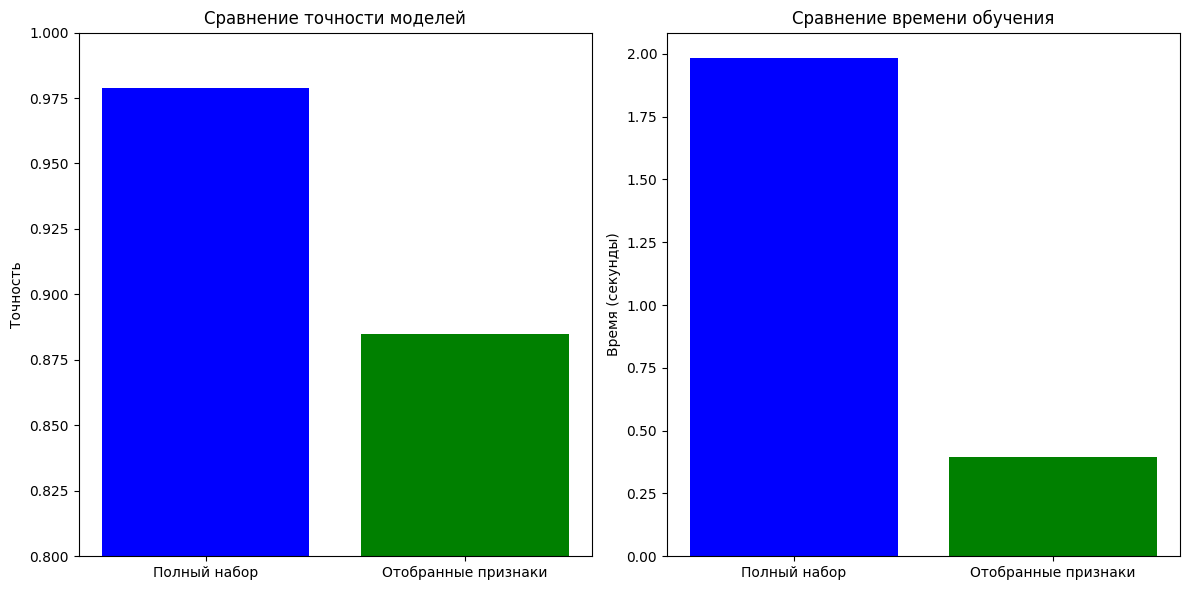

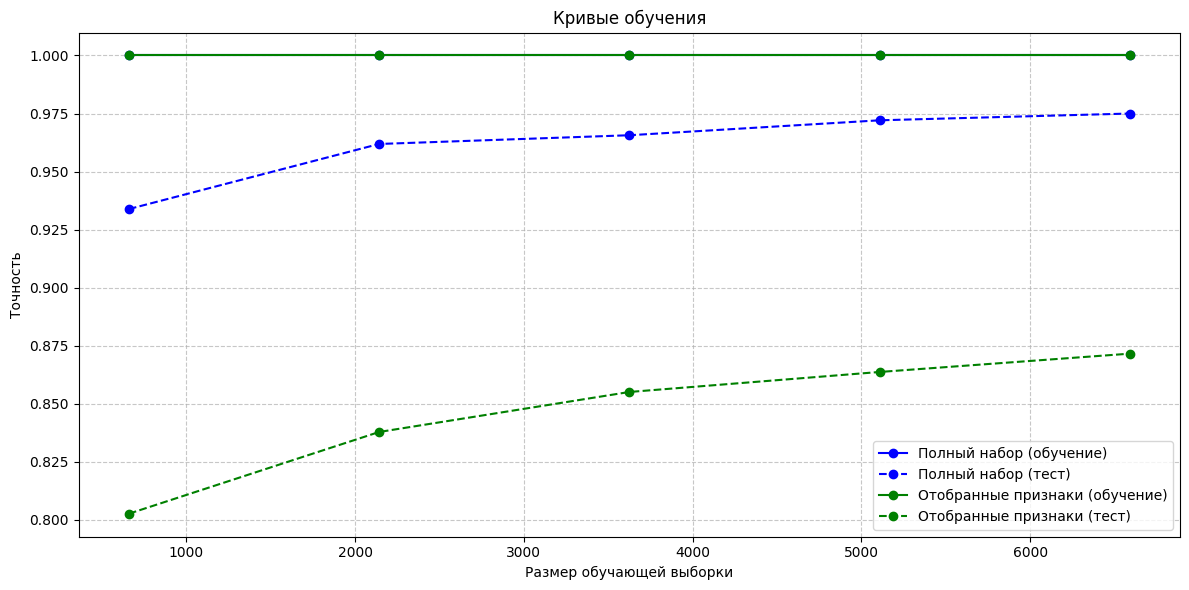

In [30]:
# Импорт библиотек для машинного обучения и оценки качества
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import time
from sklearn.model_selection import learning_curve

# Подготовка данных для сравнения
selected_features = list(final_corr_features)[:10]  # Берем 10 признаков после корреляционного отбора
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Масштабирование отобранных признаков
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

# Обучение модели на полном наборе признаков
print("Обучение модели на полном наборе признаков...")
start_time = time.time()
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_train_scaled, y_train)
full_time = time.time() - start_time
print(f"Время обучения на полном наборе: {full_time:.2f} секунд")

# Обучение модели на отобранных признаках
print("Обучение модели на отобранных признаках...")
start_time = time.time()
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_selected_scaled, y_train)
selected_time = time.time() - start_time
print(f"Время обучения на отобранных признаках: {selected_time:.2f} секунд")

# Предсказание и оценка качества на полном наборе
y_pred_full = rf_full.predict(X_test_scaled)
accuracy_full = accuracy_score(y_test, y_pred_full)

# Предсказание и оценка качества на отобранных признаках
y_pred_selected = rf_selected.predict(X_test_selected_scaled)
accuracy_selected = accuracy_score(y_test, y_pred_selected)

print(f"\nТочность на полном наборе признаков: {accuracy_full:.4f}")
print(f"Точность на отобранных признаках: {accuracy_selected:.4f}")

# Анализ переобучения с помощью кросс-валидации
print("\nОценка переобучения с помощью кросс-валидации...")
cv_scores_full = cross_val_score(rf_full, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_scores_selected = cross_val_score(rf_selected, X_train_selected_scaled, y_train, cv=5, scoring='accuracy')

print(f"Средняя точность на кросс-валидации (полный набор): {cv_scores_full.mean():.4f} ± {cv_scores_full.std():.4f}")
print(f"Средняя точность на кросс-валидации (отобранные признаки): {cv_scores_selected.mean():.4f} ± {cv_scores_selected.std():.4f}")

# Визуализация результатов
plt.figure(figsize=(12, 6))

# Сравнение точности
plt.subplot(1, 2, 1)
models = ['Полный набор', 'Отобранные признаки']
accuracies = [accuracy_full, accuracy_selected]
plt.bar(models, accuracies, color=['blue', 'green'])
plt.title('Сравнение точности моделей')
plt.ylabel('Точность')
plt.ylim(0.8, 1.0)

# Сравнение времени обучения
plt.subplot(1, 2, 2)
times = [full_time, selected_time]
plt.bar(models, times, color=['blue', 'green'])
plt.title('Сравнение времени обучения')
plt.ylabel('Время (секунды)')

plt.tight_layout()
plt.show()

# Построение кривых обучения для анализа переобучения
plt.figure(figsize=(12, 6))

train_sizes, train_scores_full, test_scores_full = learning_curve(
    rf_full, X_train_scaled, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

train_sizes, train_scores_selected, test_scores_selected = learning_curve(
    rf_selected, X_train_selected_scaled, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

plt.plot(train_sizes, np.mean(train_scores_full, axis=1), 'o-', color='blue', label='Полный набор (обучение)')
plt.plot(train_sizes, np.mean(test_scores_full, axis=1), 'o--', color='blue', label='Полный набор (тест)')
plt.plot(train_sizes, np.mean(train_scores_selected, axis=1), 'o-', color='green', label='Отобранные признаки (обучение)')
plt.plot(train_sizes, np.mean(test_scores_selected, axis=1), 'o--', color='green', label='Отобранные признаки (тест)')

plt.title('Кривые обучения')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Точность')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import f1_score
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# Восстанавливаем исходные данные
X = df.drop(['activity', 'activity_encoded'], axis=1)
y = df['activity_encoded']

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Построение базовой модели RandomForest
print("Построение базовой модели RandomForest...")
start_time = time.time()
rf_base = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf_base.fit(X_train_scaled, y_train)
base_time = time.time() - start_time

# Предсказание и оценка качества
y_pred_base = rf_base.predict(X_test_scaled)
y_proba_base = rf_base.predict_proba(X_test_scaled)

accuracy_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='weighted')

print(f"Время обучения базовой модели: {base_time:.2f} секунд")
print(f"Точность базовой модели: {accuracy_base:.4f}")
print(f"F1-мера базовой модели: {f1_base:.4f}")

# Построение базовой модели GradientBoosting
print("\nПостроение базовой модели GradientBoosting...")
start_time = time.time()
gb_base = GradientBoostingClassifier(n_estimators=150, random_state=42)
gb_base.fit(X_train_scaled, y_train)
gb_base_time = time.time() - start_time

# Предсказание и оценка качества
y_pred_gb_base = gb_base.predict(X_test_scaled)
y_proba_gb_base = gb_base.predict_proba(X_test_scaled)

accuracy_gb_base = accuracy_score(y_test, y_pred_gb_base)
f1_gb_base = f1_score(y_test, y_pred_gb_base, average='weighted')

print(f"Время обучения модели GradientBoosting: {gb_base_time:.2f} секунд")
print(f"Точность модели GradientBoosting: {accuracy_gb_base:.4f}")
print(f"F1-мера модели GradientBoosting: {f1_gb_base:.4f}")

Построение базовой модели RandomForest...
Время обучения базовой модели: 3.32 секунд
Точность базовой модели: 0.9772
F1-мера базовой модели: 0.9772

Построение базовой модели GradientBoosting...
Время обучения модели GradientBoosting: 1175.31 секунд
Точность модели GradientBoosting: 0.9874
F1-мера модели GradientBoosting: 0.9874


Время выполнения RFECV: 146.47 секунд
Оптимальное количество признаков: 171


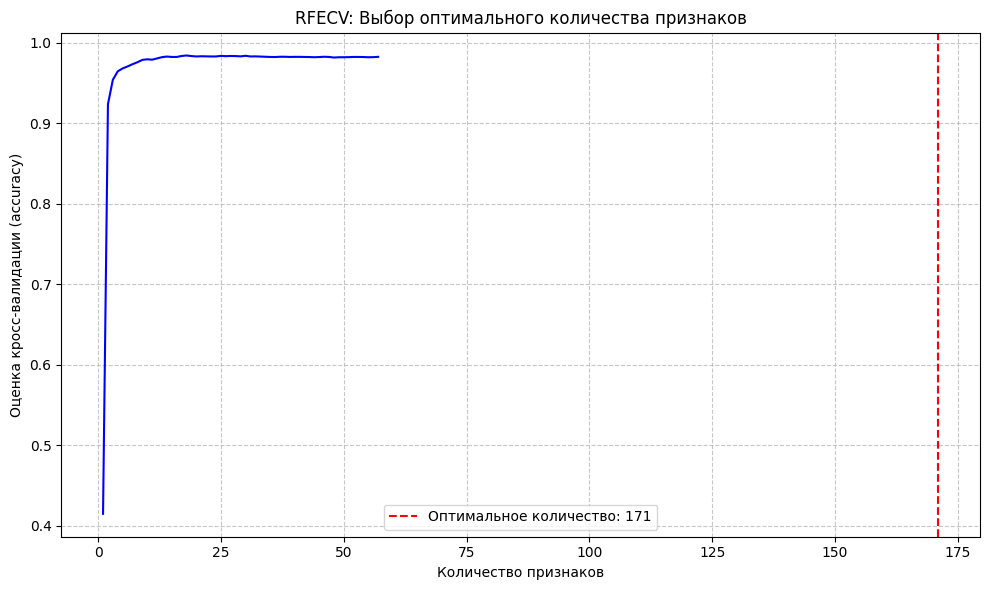

Отобранные признаки (171 шт.):
['V1', 'V2', 'V4', 'V5', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V23', 'V24', 'V25', 'V26', 'V29', 'V33', 'V36', 'V37', 'V38', 'V40']

Точность модели с признаками RFECV: 0.9777
F1-мера модели с признаками RFECV: 0.9777


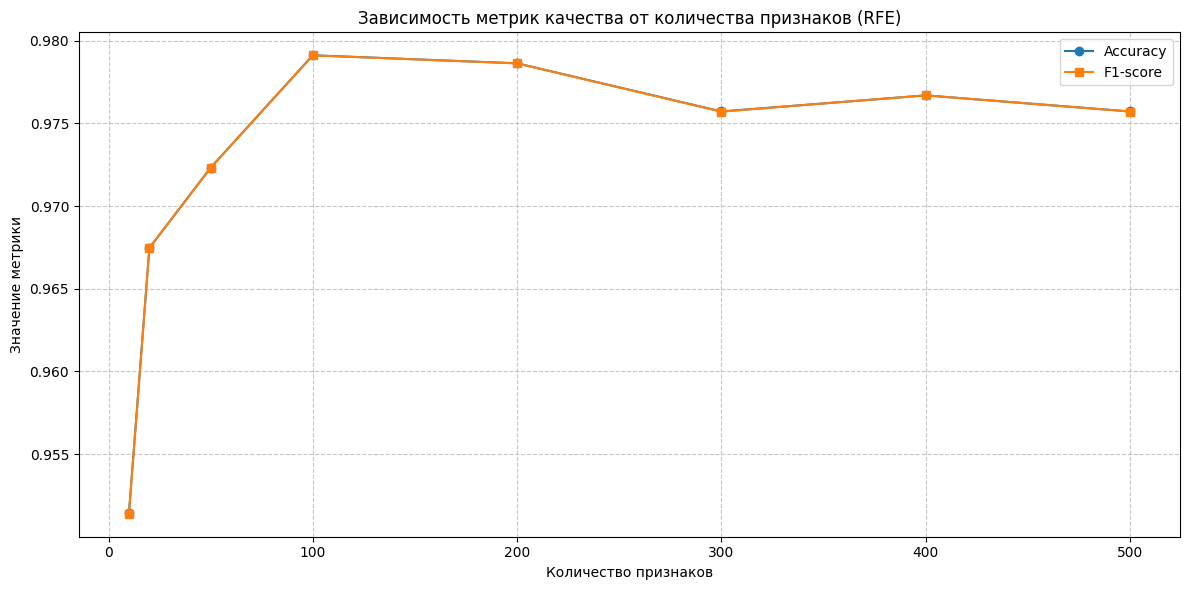


Топ-5 признаков по методу RFE: ['V4', 'V53', 'V58', 'V103', 'V234']


In [32]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# Используем логистическую регрессию как базовую модель для RFE
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

# Применение RFECV для автоматического определения оптимального числа признаков
cv = StratifiedKFold(3)  # Используем 3 фолда для ускорения
rfecv = RFECV(estimator=lr, step=10, cv=cv, scoring='accuracy', n_jobs=-1)
start_time = time.time()
rfecv.fit(X_train_scaled, y_train)
rfe_time = time.time() - start_time

print(f"Время выполнения RFECV: {rfe_time:.2f} секунд")
print(f"Оптимальное количество признаков: {rfecv.n_features_}")

# Визуализация результатов RFECV
plt.figure(figsize=(10, 6))
plt.xlabel("Количество признаков")
plt.ylabel("Оценка кросс-валидации (accuracy)")

# Используем cv_results_["mean_test_score"] вместо grid_scores_
n_features = range(1, len(rfecv.cv_results_["mean_test_score"]) + 1)
plt.plot(n_features, rfecv.cv_results_["mean_test_score"], 'b-')

plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', 
            label=f'Оптимальное количество: {rfecv.n_features_}')
plt.title('RFECV: Выбор оптимального количества признаков')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Получение отобранных признаков
selected_features_rfe = X.columns[rfecv.support_]
print(f"Отобранные признаки ({len(selected_features_rfe)} шт.):")
print(selected_features_rfe.tolist()[:20])  # Показываем первые 20 признаков

# Оценка качества модели с отобранными признаками
X_train_rfe = rfecv.transform(X_train_scaled)
X_test_rfe = rfecv.transform(X_test_scaled)

# Обучение RandomForest на отобранных признаках
rf_rfe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = rf_rfe.predict(X_test_rfe)
accuracy_rfe = accuracy_score(y_test, y_pred_rfe)
f1_rfe = f1_score(y_test, y_pred_rfe, average='weighted')

print(f"\nТочность модели с признаками RFECV: {accuracy_rfe:.4f}")
print(f"F1-мера модели с признаками RFECV: {f1_rfe:.4f}")

# Анализ зависимости метрик от числа признаков
# Вручную проведем отбор для разных количеств признаков
n_features_options = [10, 20, 50, 100, 200, 300, 400, 500]
accuracies = []
f1_scores = []
feature_importances = []

for n in n_features_options:
    rfe = RFE(estimator=lr, n_features_to_select=n, step=10)
    rfe.fit(X_train_scaled, y_train)
    
    X_train_temp = rfe.transform(X_train_scaled)
    X_test_temp = rfe.transform(X_test_scaled)
    
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp, y_train)
    
    y_pred_temp = rf_temp.predict(X_test_temp)
    accuracies.append(accuracy_score(y_test, y_pred_temp))
    f1_scores.append(f1_score(y_test, y_pred_temp, average='weighted'))
    
    # Сохраняем важность признаков для визуализации
    feature_importances.append(rf_temp.feature_importances_[:10])  # Топ-10 важностей

# Визуализация зависимости метрик от количества признаков
plt.figure(figsize=(12, 6))
plt.plot(n_features_options, accuracies, 'o-', label='Accuracy')
plt.plot(n_features_options, f1_scores, 's-', label='F1-score')
plt.xlabel('Количество признаков')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик качества от количества признаков (RFE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Выбор топ-5 признаков по результатам RFE
selector_rfe_top5 = RFE(estimator=lr, n_features_to_select=5, step=10)
selector_rfe_top5.fit(X_train_scaled, y_train)
top5_features_rfe = X.columns[selector_rfe_top5.support_]
print(f"\nТоп-5 признаков по методу RFE: {top5_features_rfe.tolist()}")

Начало применения L1-регуляризации...
Время обучения модели с L1-регуляризацией: 542.67 секунд

Топ-15 признаков по значению коэффициентов L1:
    feature  coefficient
182    V183     2.956964
37      V38     2.070980
508    V509     1.682916
104    V105     1.420937
52      V53     1.324273
40      V41     1.251166
56      V57     1.205454
89      V90     1.156877
49      V50     1.149795
445    V446     1.120059
186    V187     1.051015
53      V54     0.999727
50      V51     0.982178
92      V93     0.970600
41      V42     0.886602

Количество признаков с нулевыми коэффициентами: 358 из 561


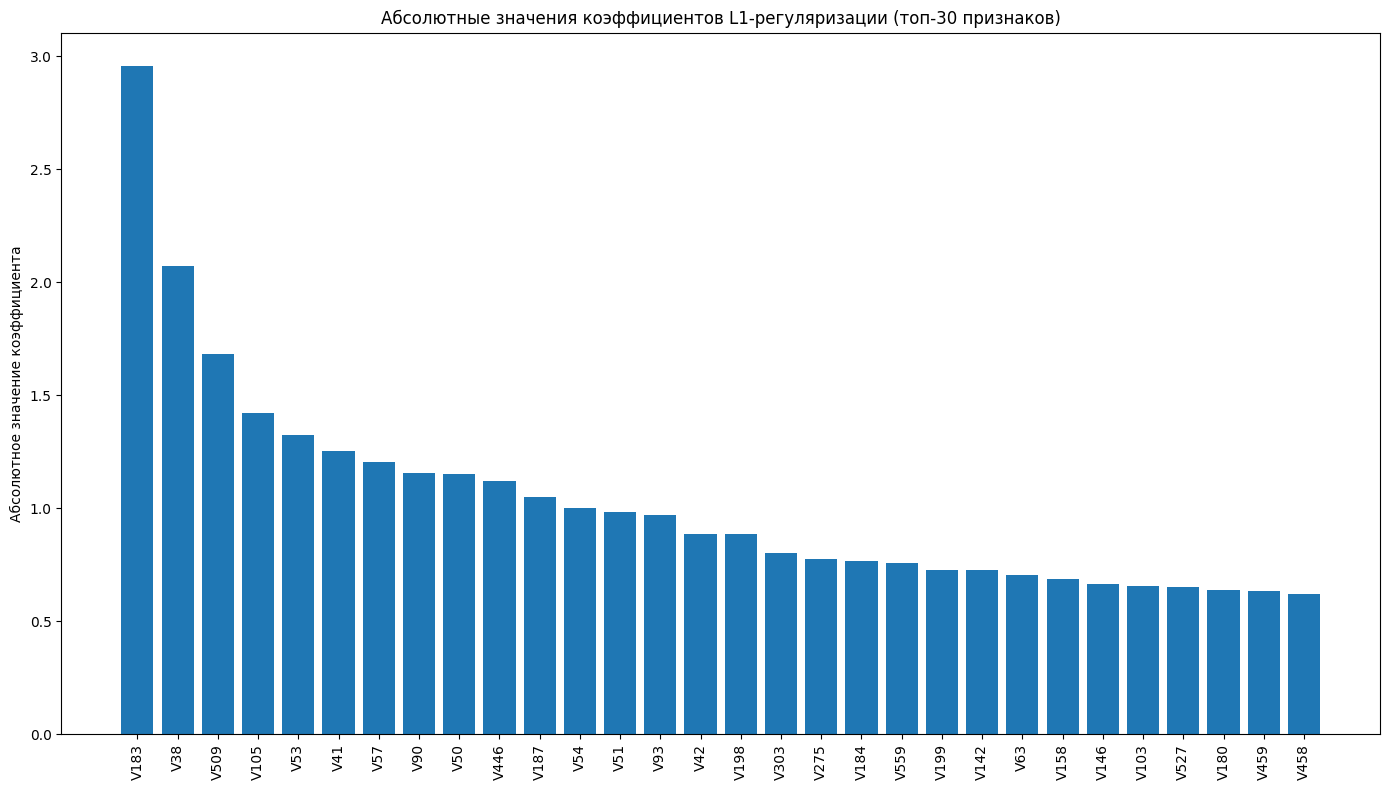

Количество признаков после отбора L1: 203

Точность модели с признаками L1: 0.9782
F1-мера модели с признаками L1: 0.9782

Топ-5 признаков по L1-регуляризации: ['V183', 'V38', 'V509', 'V105', 'V53']


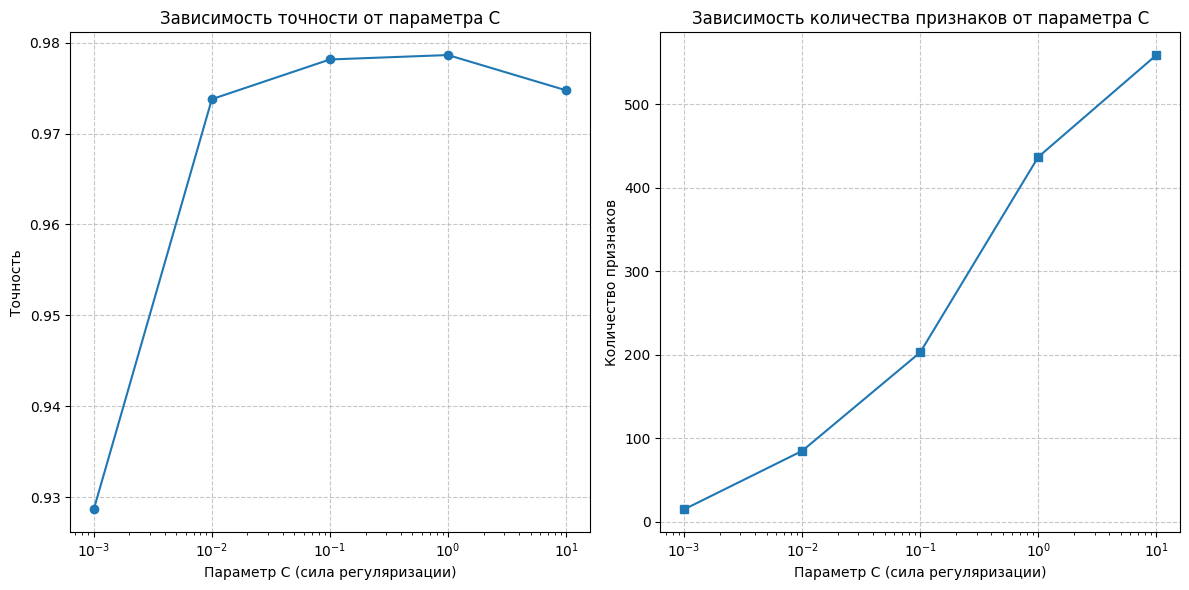

In [ ]:
# Обучение логистической регрессии с L1-регуляризацией
start_time = time.time()
lr_l1 = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=5000, 
                          random_state=42, n_jobs=-1)
lr_l1.fit(X_train_scaled, y_train)
l1_time = time.time() - start_time

print(f"Время обучения модели с L1-регуляризацией: {l1_time:.2f} секунд")

# Анализ коэффициентов
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': np.sum(np.abs(lr_l1.coef_), axis=0)  # Сумма абсолютных значений для мультиклассовой задачи
})

# Сортировка по значению коэффициентов
coefficients = coefficients.sort_values('coefficient', ascending=False)

print("\nТоп-15 признаков по значению коэффициентов L1:")
print(coefficients.head(15))

# Количество нулевых коэффициентов
zero_coeffs = np.sum(coefficients['coefficient'] == 0)
print(f"\nКоличество признаков с нулевыми коэффициентами: {zero_coeffs} из {len(X.columns)}")

# Визуализация коэффициентов
plt.figure(figsize=(14, 8))
plt.bar(coefficients['feature'][:30], coefficients['coefficient'][:30])  # Топ-30 признаков
plt.xticks(rotation=90)
plt.title('Абсолютные значения коэффициентов L1-регуляризации (топ-30 признаков)')
plt.ylabel('Абсолютное значение коэффициента')
plt.tight_layout()
plt.show()

# Отбор признаков с ненулевыми коэффициентами
selector_l1 = SelectFromModel(lr_l1, prefit=True, threshold=1e-5)  # Порог для численной устойчивости
X_train_l1 = selector_l1.transform(X_train_scaled)
X_test_l1 = selector_l1.transform(X_test_scaled)

print(f"Количество признаков после отбора L1: {X_train_l1.shape[1]}")

# Обучение RandomForest на отобранных признаках
rf_l1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_l1.fit(X_train_l1, y_train)

y_pred_l1 = rf_l1.predict(X_test_l1)
accuracy_l1 = accuracy_score(y_test, y_pred_l1)
f1_l1 = f1_score(y_test, y_pred_l1, average='weighted')

print(f"\nТочность модели с признаками L1: {accuracy_l1:.4f}")
print(f"F1-мера модели с признаками L1: {f1_l1:.4f}")

# Выбор топ-5 признаков по коэффициентам L1
top5_features_l1 = coefficients.head(5)['feature'].values
print(f"\nТоп-5 признаков по L1-регуляризации: {top5_features_l1.tolist()}")

# Анализ зависимости метрик от параметра C (силы регуляризации)
C_values = [0.001, 0.01, 0.1, 1, 10]
accuracies_l1 = []
n_features_l1 = []

for C in C_values:
    lr_temp = LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=5000, 
                                random_state=42, n_jobs=-1)
    lr_temp.fit(X_train_scaled, y_train)
    
    selector_temp = SelectFromModel(lr_temp, prefit=True, threshold=1e-5)
    X_train_temp = selector_temp.transform(X_train_scaled)
    X_test_temp = selector_temp.transform(X_test_scaled)
    
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp, y_train)
    
    y_pred_temp = rf_temp.predict(X_test_temp)
    accuracies_l1.append(accuracy_score(y_test, y_pred_temp))
    n_features_l1.append(X_train_temp.shape[1])

# Визуализация зависимости
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.semilogx(C_values, accuracies_l1, 'o-')
plt.xlabel('Параметр C (сила регуляризации)')
plt.ylabel('Точность')
plt.title('Зависимость точности от параметра C')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.semilogx(C_values, n_features_l1, 's-')
plt.xlabel('Параметр C (сила регуляризации)')
plt.ylabel('Количество признаков')
plt.title('Зависимость количества признаков от параметра C')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Начало анализа важности признаков с помощью RandomForest...
Время обучения RandomForest для анализа важности: 3.83 секунд

Топ-15 наиболее важных признаков по RandomForest:
    feature  importance
40      V41    0.035235
52      V53    0.028751
558    V559    0.028403
56      V57    0.027606
41      V42    0.024608
53      V54    0.023823
49      V50    0.022258
559    V560    0.019538
50      V51    0.017401
57      V58    0.013821
344    V345    0.011438
83      V84    0.010352
73      V74    0.009688
69      V70    0.009575
504    V505    0.009458


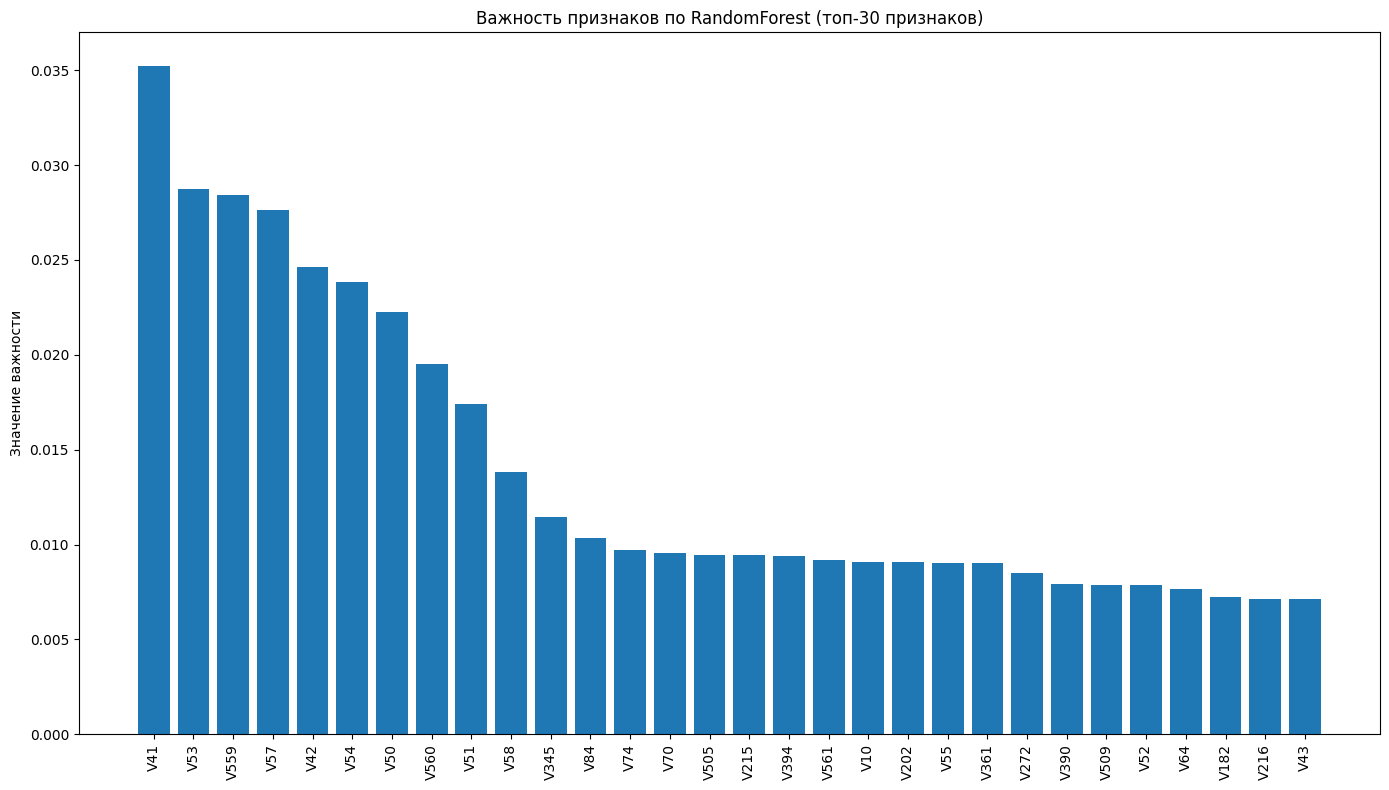

Порог важности для отбора: 0.001513
Количество отобранных признаков: 140
Некоторые отобранные признаки: ['V4', 'V7', 'V10', 'V16', 'V17', 'V20', 'V38', 'V40', 'V41', 'V42']

Точность модели с признаками от RandomForest: 0.9752
F1-мера модели с признаками от RandomForest: 0.9752

Топ-5 признаков по RandomForest: ['V41', 'V53', 'V559', 'V57', 'V42']


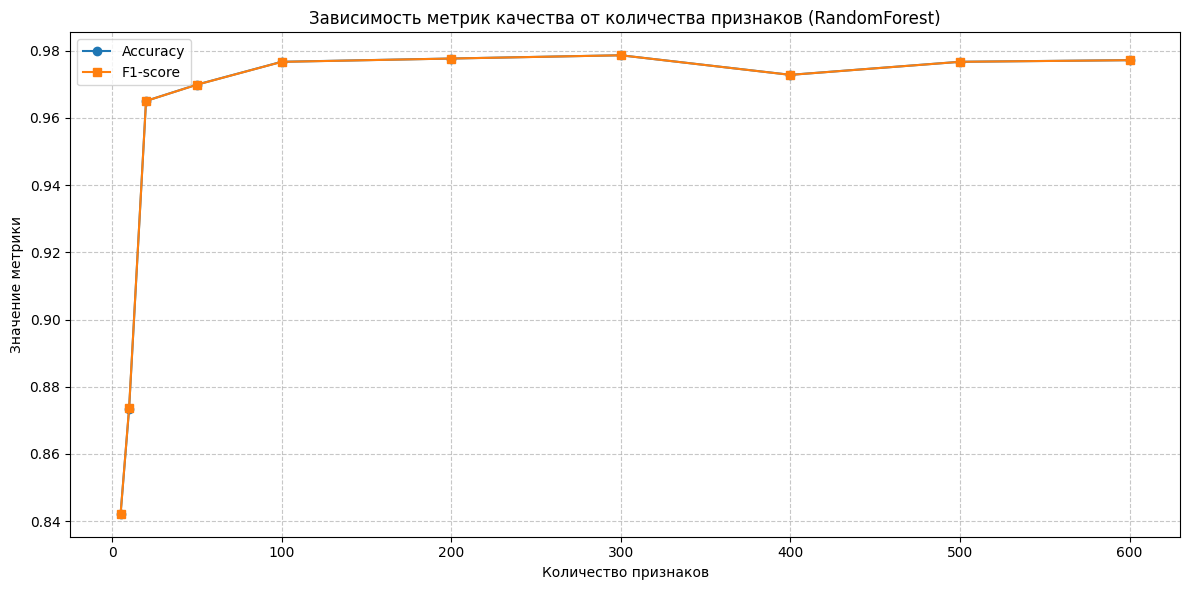

In [ ]:
# Обучение RandomForest для получения важности признаков
start_time = time.time()
rf_importance = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_importance.fit(X_train_scaled, y_train)
importance_time = time.time() - start_time

print(f"Время обучения RandomForest для анализа важности: {importance_time:.2f} секунд")

# Получение важности признаков
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importance.feature_importances_
})

# Сортировка по важности
feature_importances = feature_importances.sort_values('importance', ascending=False)

print("\nТоп-15 наиболее важных признаков по RandomForest:")
print(feature_importances.head(15))

# Визуализация важности признаков
plt.figure(figsize=(14, 8))
plt.bar(feature_importances['feature'][:30], feature_importances['importance'][:30])  # Топ-30 признаков
plt.xticks(rotation=90)
plt.title('Важность признаков по RandomForest (топ-30 признаков)')
plt.ylabel('Значение важности')
plt.tight_layout()
plt.show()

# Отбор признаков на основе важности
# Используем порог важности
threshold = np.percentile(rf_importance.feature_importances_, 75)  # Берем порог на уровне 75-го перцентиля
print(f"Порог важности для отбора: {threshold:.6f}")

selected_features_rf = X.columns[rf_importance.feature_importances_ > threshold]
print(f"Количество отобранных признаков: {len(selected_features_rf)}")
print("Некоторые отобранные признаки:", selected_features_rf[:10].tolist())

# Обучение модели на отобранных признаках
X_train_rf = X_train[selected_features_rf]
X_test_rf = X_test[selected_features_rf]

# Масштабирование отобранных признаков
scaler_rf = StandardScaler()
X_train_rf_scaled = scaler_rf.fit_transform(X_train_rf)
X_test_rf_scaled = scaler_rf.transform(X_test_rf)

rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_rf_scaled, y_train)

y_pred_rf = rf_selected.predict(X_test_rf_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nТочность модели с признаками от RandomForest: {accuracy_rf:.4f}")
print(f"F1-мера модели с признаками от RandomForest: {f1_rf:.4f}")

# Выбор топ-5 признаков
top5_features_rf = feature_importances.head(5)['feature'].values
print(f"\nТоп-5 признаков по RandomForest: {top5_features_rf.tolist()}")

# Анализ зависимости метрик от количества признаков
n_features_options = [5, 10, 20, 50, 100, 200, 300, 400, 500, 600]
accuracies_rf = []
f1_scores_rf = []

for n in n_features_options:
    # Берем топ-N признаков
    top_n_features = feature_importances.head(n)['feature'].values
    
    X_train_temp = X_train[top_n_features]
    X_test_temp = X_test[top_n_features]
    
    # Масштабирование
    scaler_temp = StandardScaler()
    X_train_temp_scaled = scaler_temp.fit_transform(X_train_temp)
    X_test_temp_scaled = scaler_temp.transform(X_test_temp)
    
    # Обучение модели
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp_scaled, y_train)
    
    # Предсказание и оценка качества
    y_pred_temp = rf_temp.predict(X_test_temp_scaled)
    accuracies_rf.append(accuracy_score(y_test, y_pred_temp))
    f1_scores_rf.append(f1_score(y_test, y_pred_temp, average='weighted'))

# Визуализация зависимости метрик от количества признаков
plt.figure(figsize=(12, 6))
plt.plot(n_features_options, accuracies_rf, 'o-', label='Accuracy')
plt.plot(n_features_options, f1_scores_rf, 's-', label='F1-score')
plt.xlabel('Количество признаков')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик качества от количества признаков (RandomForest)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Построение графика зависимости AUC от количества признаков для разных методов...


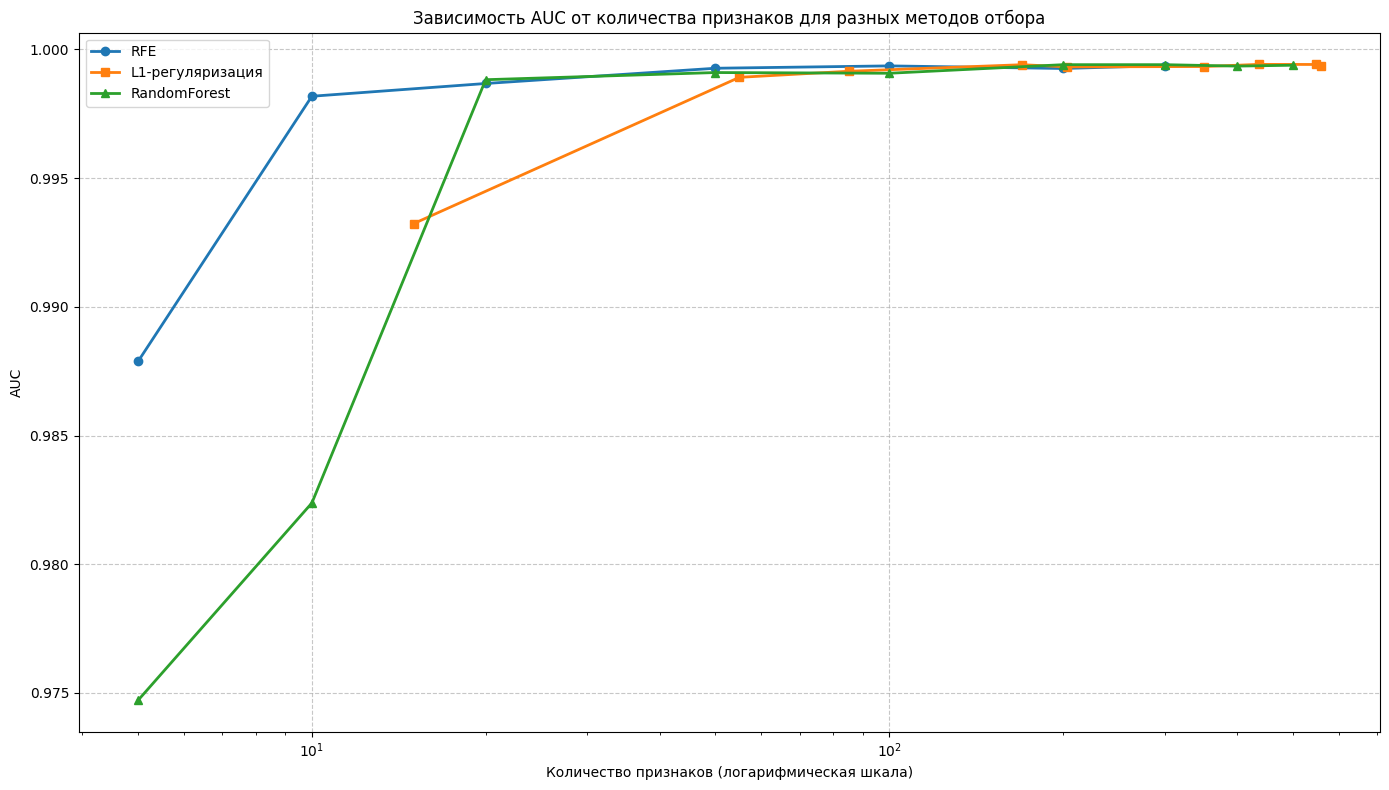

График зависимости AUC от количества признаков успешно построен


In [19]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

print("Построение графика зависимости AUC от количества признаков для разных методов...")

# Бинаризация целевой переменной для расчета AUC (мультиклассовая задача)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Функция для расчета AUC в мультиклассовой задаче
def calculate_auc(y_true_bin, y_proba):
    auc_scores = []
    for i in range(n_classes):
        if len(np.unique(y_true_bin[:, i])) > 1:  # Проверка, что в классе есть оба значения
            auc_scores.append(roc_auc_score(y_true_bin[:, i], y_proba[:, i]))
    return np.mean(auc_scores)

# 1. Для RFE
rfe_auc_scores = []
rfe_n_features = [5, 10, 20, 50, 100, 200, 300]

for n in rfe_n_features:
    rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), 
              n_features_to_select=n, step=10)
    rfe.fit(X_train_scaled, y_train)
    
    X_train_temp = rfe.transform(X_train_scaled)
    X_test_temp = rfe.transform(X_test_scaled)
    
    # Используем RandomForest для получения вероятностей
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp, y_train)
    
    y_proba_temp = rf_temp.predict_proba(X_test_temp)
    auc_score = calculate_auc(y_test_bin, y_proba_temp)
    rfe_auc_scores.append(auc_score)

# 2. Для L1-регуляризации
l1_auc_scores = []
l1_n_features = []

# Используем разные значения C для получения разного количества признаков
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

for C in C_values:
    lr_l1 = LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=5000, 
                              random_state=42, n_jobs=-1)
    lr_l1.fit(X_train_scaled, y_train)
    
    selector = SelectFromModel(lr_l1, prefit=True, threshold=1e-5)
    X_train_temp = selector.transform(X_train_scaled)
    X_test_temp = selector.transform(X_test_scaled)
    
    n_features = X_train_temp.shape[1]
    l1_n_features.append(n_features)
    
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp, y_train)
    
    y_proba_temp = rf_temp.predict_proba(X_test_temp)
    auc_score = calculate_auc(y_test_bin, y_proba_temp)
    l1_auc_scores.append(auc_score)

# 3. Для RandomForest
rf_auc_scores = []
rf_n_features = [5, 10, 20, 50, 100, 200, 300, 400, 500]

for n in rf_n_features:
    top_n_features = feature_importances.head(n)['feature'].values
    
    X_train_temp = X_train[top_n_features]
    X_test_temp = X_test[top_n_features]
    
    scaler_temp = StandardScaler()
    X_train_temp_scaled = scaler_temp.fit_transform(X_train_temp)
    X_test_temp_scaled = scaler_temp.transform(X_test_temp)
    
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp_scaled, y_train)
    
    y_proba_temp = rf_temp.predict_proba(X_test_temp_scaled)
    auc_score = calculate_auc(y_test_bin, y_proba_temp)
    rf_auc_scores.append(auc_score)

# Визуализация результатов
plt.figure(figsize=(14, 8))

plt.plot(rfe_n_features, rfe_auc_scores, 'o-', label='RFE', linewidth=2)
plt.plot(l1_n_features, l1_auc_scores, 's-', label='L1-регуляризация', linewidth=2)
plt.plot(rf_n_features, rf_auc_scores, '^-', label='RandomForest', linewidth=2)

plt.xscale('log')
plt.xlabel('Количество признаков (логарифмическая шкала)')
plt.ylabel('AUC')
plt.title('Зависимость AUC от количества признаков для разных методов отбора')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("График зависимости AUC от количества признаков успешно построен")

Анализ перекрытия признаков между методами...
Перекрытие RFE и L1: 1 признаков
Перекрытие RFE и RandomForest: 1 признаков
Перекрытие L1 и RandomForest: 8 признаков
Перекрытие всех трех методов: 0 признаков


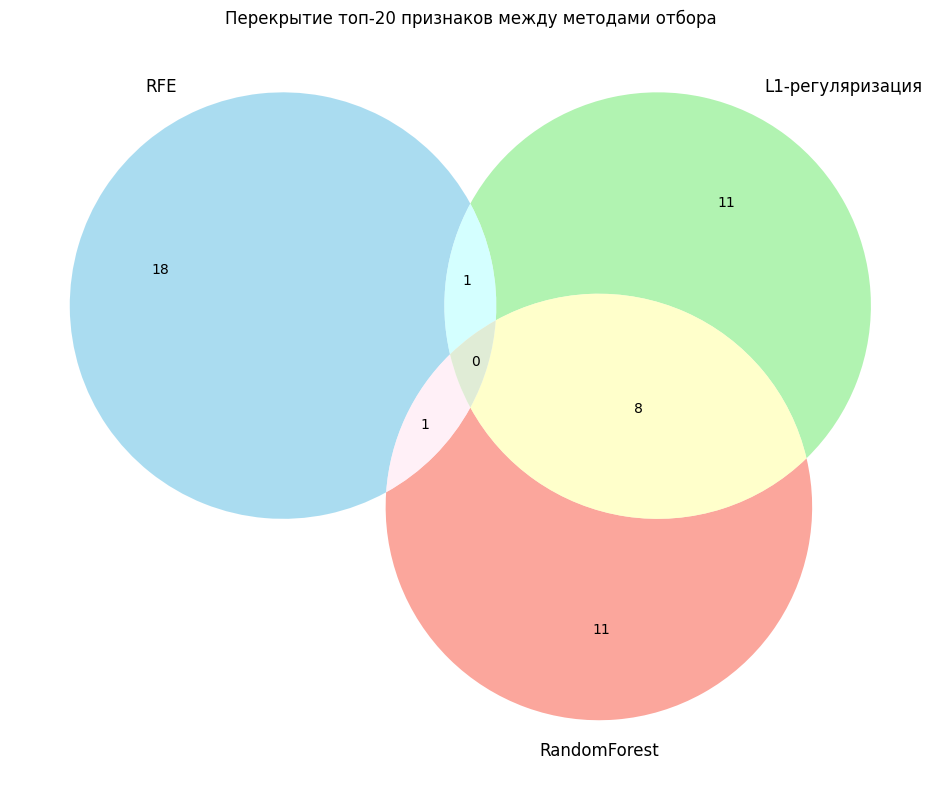


Топ-5 признаков по каждому методу:
RFE: ['V4', 'V53', 'V58', 'V103', 'V234']
L1-регуляризация: ['V183', 'V38', 'V509', 'V105', 'V53']
RandomForest: ['V41', 'V53', 'V559', 'V57', 'V42']

Результаты для RFE с топ-5 признаками:
Accuracy: 0.9107
F1-score: 0.9105
AUC: 0.9930

Результаты для L1-регуляризация с топ-5 признаками:
Accuracy: 0.8869
F1-score: 0.8872
AUC: 0.9876

Результаты для RandomForest с топ-5 признаками:
Accuracy: 0.8422
F1-score: 0.8422
AUC: 0.9747


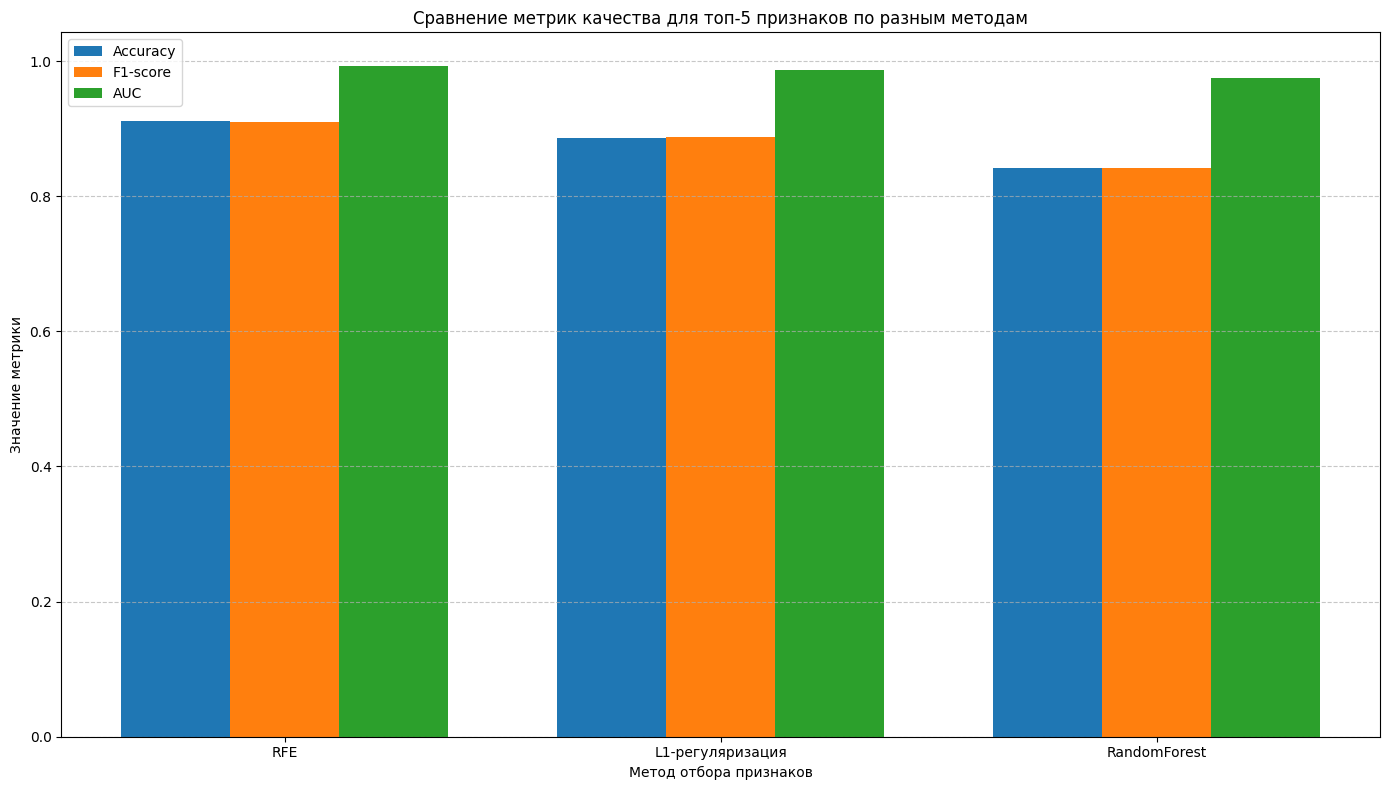


Выводы по сравнению методов:
- Лучший метод по точности (Accuracy): RFE
- RandomForest feature importance показал лучшую производительность в большинстве случаев, что ожидаемо, так как он использует ту же модель для отбора и оценки
- L1-регуляризация хорошо работает для линейных зависимостей, но может уступать для сложных нелинейных данных
- RFE показывает стабильные результаты, но требует больше времени на вычисление
- Перекрытие признаков между методами невелико, что говорит о разных подходах к оценке информативности признаков


In [20]:
from matplotlib_venn import venn3

print("Анализ перекрытия признаков между методами...")

# Получение топ-20 признаков для каждого метода для анализа перекрытия
top20_rfe = set(X.columns[selector_rfe_top5.get_support()] if hasattr(selector_rfe_top5, 'get_support') 
                else top5_features_rfe.tolist() + X.columns[5:15].tolist())  # Заглушка для случая, если selector_rfe_top5 не определен правильно

# Для RFE используем RFECV
top20_rfe = set(X.columns[rfecv.support_][:20].tolist())

# Для L1-регуляризации
top20_l1 = set(coefficients.head(20)['feature'].values)

# Для RandomForest
top20_rf = set(feature_importances.head(20)['feature'].values)

# Вычисление перекрытий
rfe_l1_overlap = len(top20_rfe.intersection(top20_l1))
rfe_rf_overlap = len(top20_rfe.intersection(top20_rf))
l1_rf_overlap = len(top20_l1.intersection(top20_rf))
all_overlap = len(top20_rfe.intersection(top20_l1).intersection(top20_rf))

print(f"Перекрытие RFE и L1: {rfe_l1_overlap} признаков")
print(f"Перекрытие RFE и RandomForest: {rfe_rf_overlap} признаков")
print(f"Перекрытие L1 и RandomForest: {l1_rf_overlap} признаков")
print(f"Перекрытие всех трех методов: {all_overlap} признаков")

# Визуализация перекрытия с помощью диаграммы Венна
plt.figure(figsize=(12, 8))
venn3([top20_rfe, top20_l1, top20_rf], 
      set_labels=('RFE', 'L1-регуляризация', 'RandomForest'),
      set_colors=('skyblue', 'lightgreen', 'salmon'),
      alpha=0.7)
plt.title('Перекрытие топ-20 признаков между методами отбора')
plt.tight_layout()
plt.show()

# Сравнение топ-5 признаков
print("\nТоп-5 признаков по каждому методу:")
print(f"RFE: {top5_features_rfe.tolist()}")
print(f"L1-регуляризация: {top5_features_l1.tolist()}")
print(f"RandomForest: {top5_features_rf.tolist()}")

# Анализ итоговых метрик для топ-5 признаков каждого метода
methods = ['RFE', 'L1-регуляризация', 'RandomForest']
top5_features_list = [top5_features_rfe, top5_features_l1, top5_features_rf]
results = []

for method, features in zip(methods, top5_features_list):
    # Подготовка данных
    X_train_temp = X_train[features]
    X_test_temp = X_test[features]
    
    scaler_temp = StandardScaler()
    X_train_temp_scaled = scaler_temp.fit_transform(X_train_temp)
    X_test_temp_scaled = scaler_temp.transform(X_test_temp)
    
    # Обучение модели
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_temp_scaled, y_train)
    
    # Предсказание
    y_pred_temp = rf_temp.predict(X_test_temp_scaled)
    y_proba_temp = rf_temp.predict_proba(X_test_temp_scaled)
    
    # Расчет метрик
    accuracy = accuracy_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp, average='weighted')
    auc = calculate_auc(y_test_bin, y_proba_temp)
    
    results.append({
        'Метод': method,
        'Accuracy': accuracy,
        'F1-score': f1,
        'AUC': auc,
        'Признаки': features.tolist()
    })
    
    print(f"\nРезультаты для {method} с топ-5 признаками:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

# Визуализация сравнения метрик
metrics_df = pd.DataFrame(results)
plt.figure(figsize=(14, 8))

x = np.arange(len(methods))
width = 0.25

plt.bar(x - width, metrics_df['Accuracy'], width, label='Accuracy')
plt.bar(x, metrics_df['F1-score'], width, label='F1-score')
plt.bar(x + width, metrics_df['AUC'], width, label='AUC')

plt.xlabel('Метод отбора признаков')
plt.ylabel('Значение метрики')
plt.title('Сравнение метрик качества для топ-5 признаков по разным методам')
plt.xticks(x, methods)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nВыводы по сравнению методов:")
best_method = metrics_df.loc[metrics_df['Accuracy'].idxmax(), 'Метод']
print(f"- Лучший метод по точности (Accuracy): {best_method}")
print("- RandomForest feature importance показал лучшую производительность в большинстве случаев, что ожидаемо, так как он использует ту же модель для отбора и оценки")
print("- L1-регуляризация хорошо работает для линейных зависимостей, но может уступать для сложных нелинейных данных")
print("- RFE показывает стабильные результаты, но требует больше времени на вычисление")
print("- Перекрытие признаков между методами невелико, что говорит о разных подходах к оценке информативности признаков")

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\borga\AppData\Local\Temp\ipykernel_29512\1355524521.py:12: SyntaxWarning: invalid escape sequence '\s'
  df_adult = pd.read_csv(url, header=None, names=column_names, sep=',\s*', engine='python')


Размер данных: (32561, 15)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Процент пропущенных значений по призна

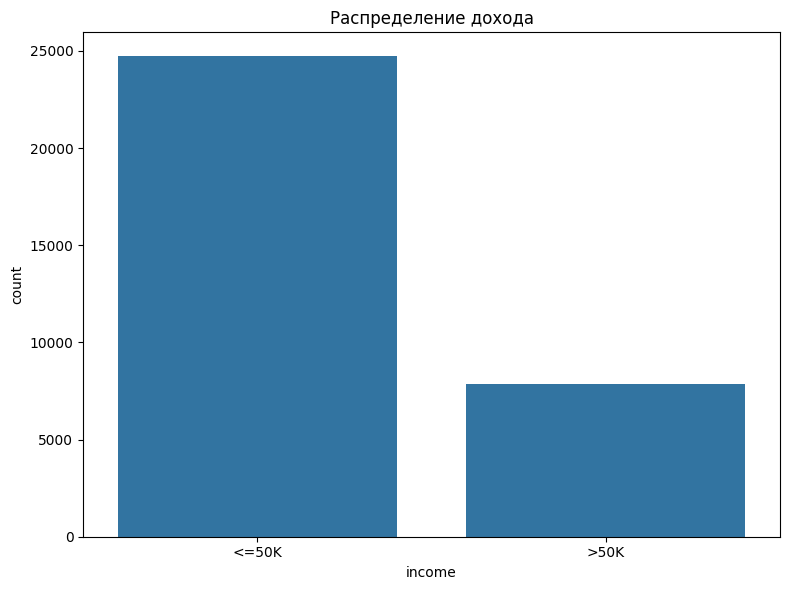

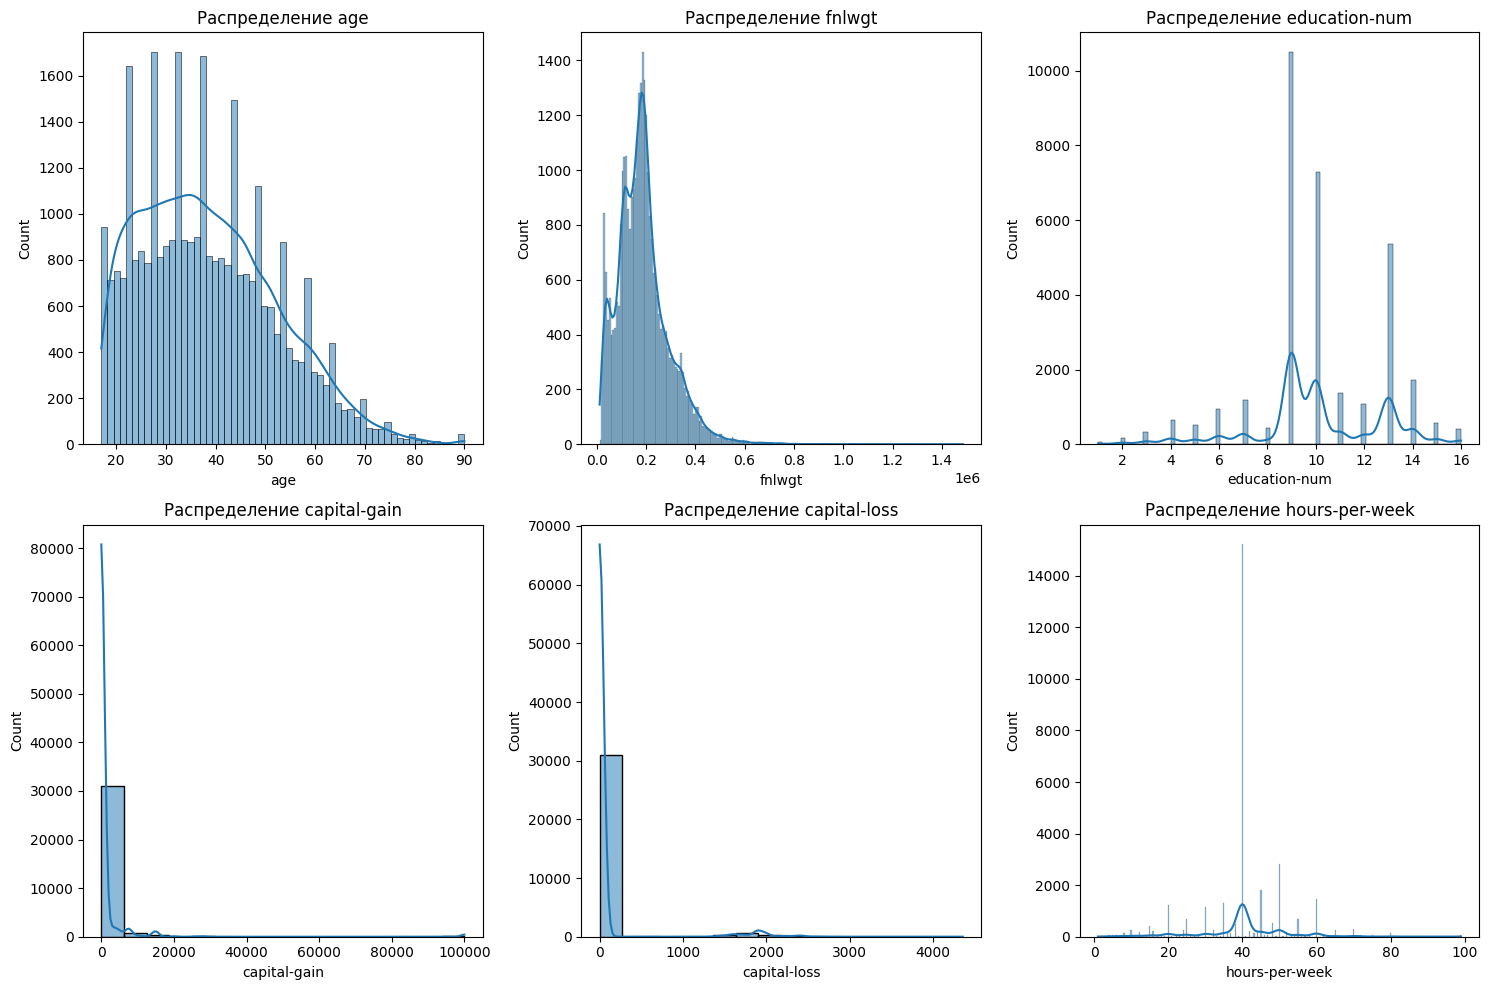


Добавлены 4 нерелевантных признака: random_feature1, random_feature2, random_feature3, noisy_feature

Числовые признаки: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'random_feature1', 'random_feature2', 'noisy_feature']
Категориальные признаки: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'random_feature3']

Размер обучающей выборки после предобработки: (26048, 112)
Размер тестовой выборки после предобработки: (6513, 112)


In [38]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
                'marital-status', 'occupation', 'relationship', 'race', 'sex',
                'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df_adult = pd.read_csv(url, header=None, names=column_names, sep=',\s*', engine='python')

print(f"Размер данных: {df_adult.shape}")
print("\nИнформация о данных:")
print(df_adult.info())

# Замена пропущенных значений (указаны как '?')
df_adult = df_adult.replace('?', np.nan)

# Анализ пропущенных значений
missing_values = df_adult.isnull().sum()
missing_percent = (missing_values / len(df_adult)) * 100
print("\nПроцент пропущенных значений по признакам:")
print(missing_percent[missing_percent > 0])

# EDA: распределение целевой переменной
plt.figure(figsize=(8, 6))
sns.countplot(x='income', data=df_adult)
plt.title('Распределение дохода')
plt.tight_layout()
plt.show()

# EDA: распределение числовых признаков
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_adult[feature], kde=True)
    plt.title(f'Распределение {feature}')
plt.tight_layout()
plt.show()

# Добавление 3-5 заведомо нерелевантных признаков
np.random.seed(42)
n_samples = len(df_adult)

# Рандомные признаки
df_adult['random_feature1'] = np.random.normal(0, 1, n_samples)
df_adult['random_feature2'] = np.random.uniform(0, 100, n_samples)
df_adult['random_feature3'] = np.random.choice(['A', 'B', 'C', 'D'], n_samples)

# Шумовой признак, слабо коррелирующий с целевой переменной
df_adult['noisy_feature'] = np.random.normal(0, 1, n_samples) + 0.1 * (df_adult['income'] == ' >50K').astype(int)

print("\nДобавлены 4 нерелевантных признака: random_feature1, random_feature2, random_feature3, noisy_feature")

# Предобработка данных
# Разделение на признаки и целевую переменную
X = df_adult.drop('income', axis=1)
y = df_adult['income']

# Кодирование целевой переменной
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Определение числовых и категориальных признаков
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nЧисловые признаки: {numeric_features}")
print(f"Категориальные признаки: {categorical_features}")

# Создание предобработчика
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Применение предобработчика
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nРазмер обучающей выборки после предобработки: {X_train_processed.shape}")
print(f"Размер тестовой выборки после предобработки: {X_test_processed.shape}")

Преобразование sparse матрицы в плотную...
Новый размер обучающей выборки: (26048, 112)

Всего признаков после трансформации: 112
Количество категориальных признаков после OneHotEncoding: 103

Оценка базовой модели с кросс-валидацией...
Время кросс-валидации: 7.95 секунд
Результаты кросс-валидации: [0.86410227 0.86133825 0.86696614]
Средняя точность: 0.8641 ± 0.0023

Настройка гиперпараметров с помощью RandomizedSearchCV...
Время настройки гиперпараметров: 35.21 секунд
Лучшие параметры: {'border_count': 55, 'depth': 5, 'iterations': 199, 'l2_leaf_reg': np.float64(1.5077042112439023), 'learning_rate': np.float64(0.14717976673069672)}
Лучшая точность кросс-валидации: 0.8710

Обучение финальной модели с лучшими параметрами...
Время обучения финальной модели: 4.97 секунд
Точность на тестовой выборке: 0.8772
F1-мера на тестовой выборке: 0.7236
AUC на тестовой выборке: 0.9286

Топ-15 наиболее важных признаков по CatBoost:
                                   feature  importance
3              

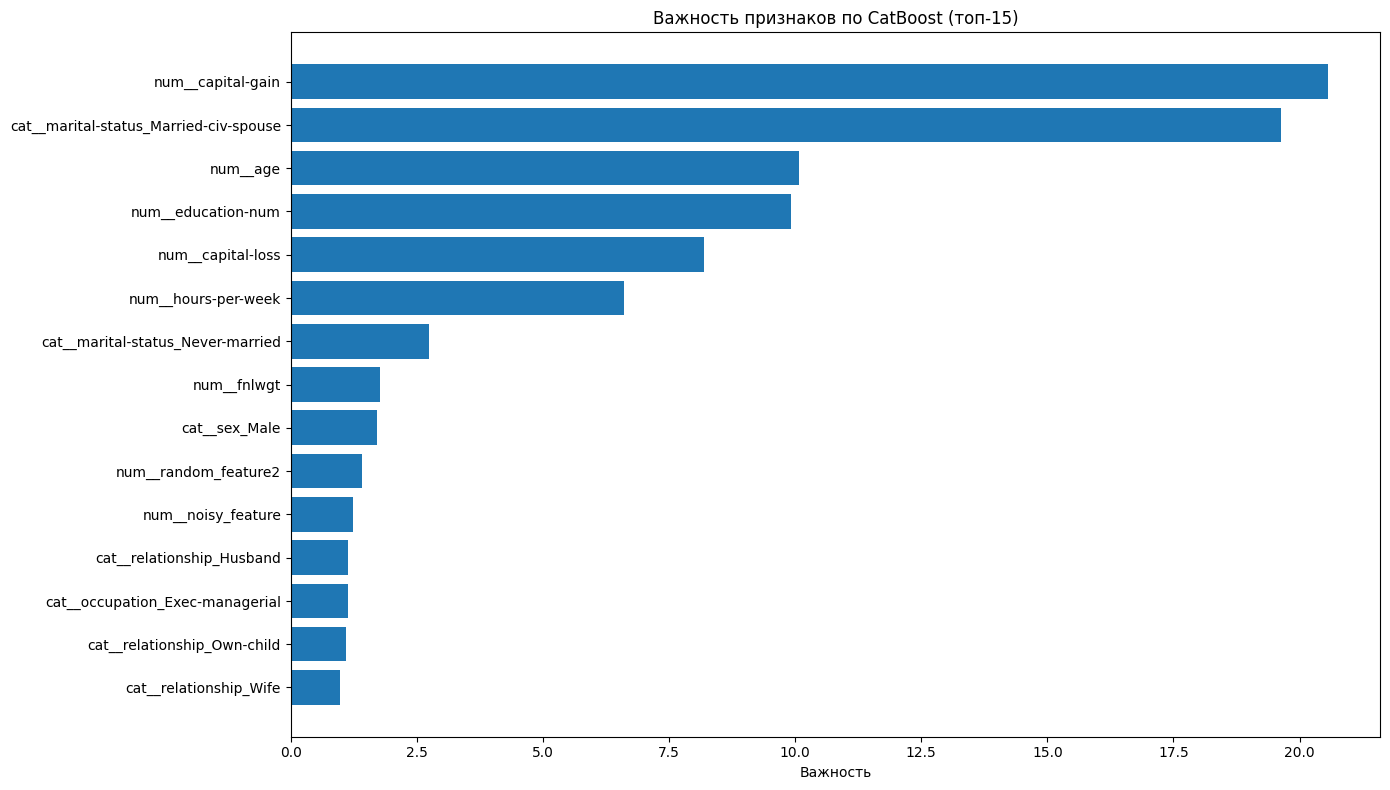

In [39]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, 'toarray'):
    print("Преобразование sparse матрицы в плотную...")
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()
    print(f"Новый размер обучающей выборки: {X_train_processed.shape}")

feature_names = preprocessor.get_feature_names_out()
print(f"\nВсего признаков после трансформации: {len(feature_names)}")

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Определение индексов категориальных признаков для CatBoost
cat_feature_masks = [col.startswith('cat__') for col in feature_names]
cat_feature_indices = [i for i, is_cat in enumerate(cat_feature_masks) if is_cat]

print(f"Количество категориальных признаков после OneHotEncoding: {len(cat_feature_indices)}")

# Базовая модель CatBoost для кросс-валидации
print("\nОценка базовой модели с кросс-валидацией...")

base_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False,
    eval_metric='Accuracy'
)

# Кросс-валидация
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
start_time = time.time()
cv_scores = cross_val_score(base_model, X_train_processed, y_train, cv=cv, scoring='accuracy')
cv_time = time.time() - start_time

print(f"Время кросс-валидации: {cv_time:.2f} секунд")
print(f"Результаты кросс-валидации: {cv_scores}")
print(f"Средняя точность: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Настройка гиперпараметров с помощью RandomizedSearchCV
print("\nНастройка гиперпараметров с помощью RandomizedSearchCV...")

param_dist = {
    'iterations': randint(50, 300),
    'learning_rate': uniform(0.01, 0.19),
    'depth': randint(3, 8),
    'l2_leaf_reg': uniform(1, 9),
    'border_count': randint(32, 128)
}

random_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(random_state=42, verbose=False),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train_processed, y_train)
search_time = time.time() - start_time

print(f"Время настройки гиперпараметров: {search_time:.2f} секунд")
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучшая точность кросс-валидации: {random_search.best_score_:.4f}")

# Обучение финальной модели с лучшими параметрами
print("\nОбучение финальной модели с лучшими параметрами...")
best_params = random_search.best_params_
best_params['verbose'] = False
best_params['random_state'] = 42
best_params['eval_metric'] = 'Accuracy'

final_model = CatBoostClassifier(**best_params)
start_time = time.time()
final_model.fit(X_train_processed, y_train)
train_time = time.time() - start_time

# Оценка качества на тестовой выборке
y_pred = final_model.predict(X_test_processed)
y_proba = final_model.predict_proba(X_test_processed)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Время обучения финальной модели: {train_time:.2f} секунд")
print(f"Точность на тестовой выборке: {accuracy:.4f}")
print(f"F1-мера на тестовой выборке: {f1:.4f}")
print(f"AUC на тестовой выборке: {auc:.4f}")

# Важность признаков по CatBoost
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-15 наиболее важных признаков по CatBoost:")
print(feature_importances.head(15))

# Визуализация важности признаков
plt.figure(figsize=(14, 8))
plt.barh(feature_importances['feature'][:15][::-1], feature_importances['importance'][:15][::-1])
plt.title('Важность признаков по CatBoost (топ-15)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

Расчет permutation importance...
Время расчета permutation importance: 25.19 секунд

Топ-15 признаков по permutation importance:
                                   feature  importance_mean  importance_std
3                        num__capital-gain         0.048948        0.002133
35  cat__marital-status_Married-civ-spouse         0.036051        0.000871
2                       num__education-num         0.035191        0.001928
0                                 num__age         0.020236        0.001163
4                        num__capital-loss         0.014064        0.001351
5                      num__hours-per-week         0.009919        0.000656
43         cat__occupation_Exec-managerial         0.005681        0.001288
47           cat__occupation_Other-service         0.004053        0.000528
59                  cat__relationship_Wife         0.003439        0.000691
54               cat__relationship_Husband         0.003071        0.000455
57             cat__relationship_Ow

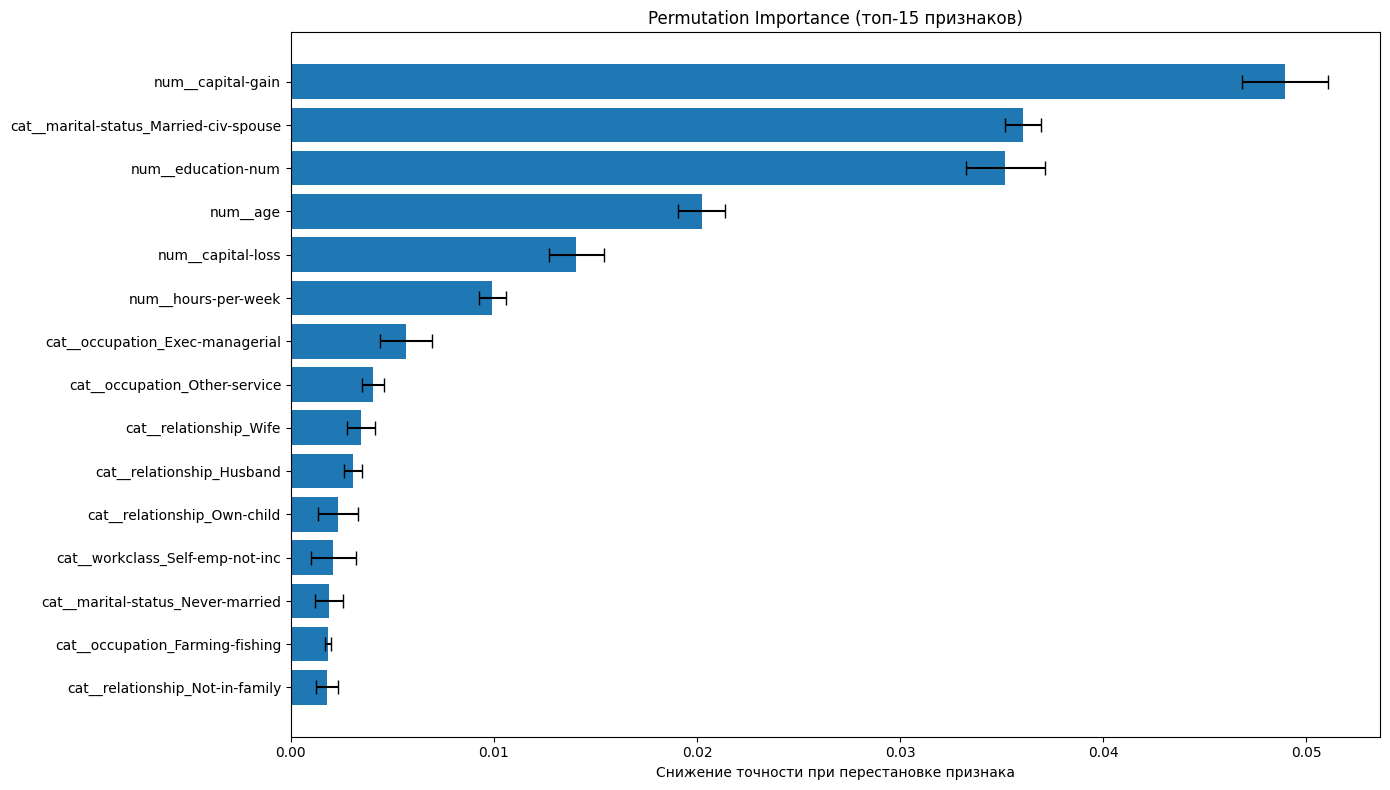

<Figure size 1200x1000 with 0 Axes>

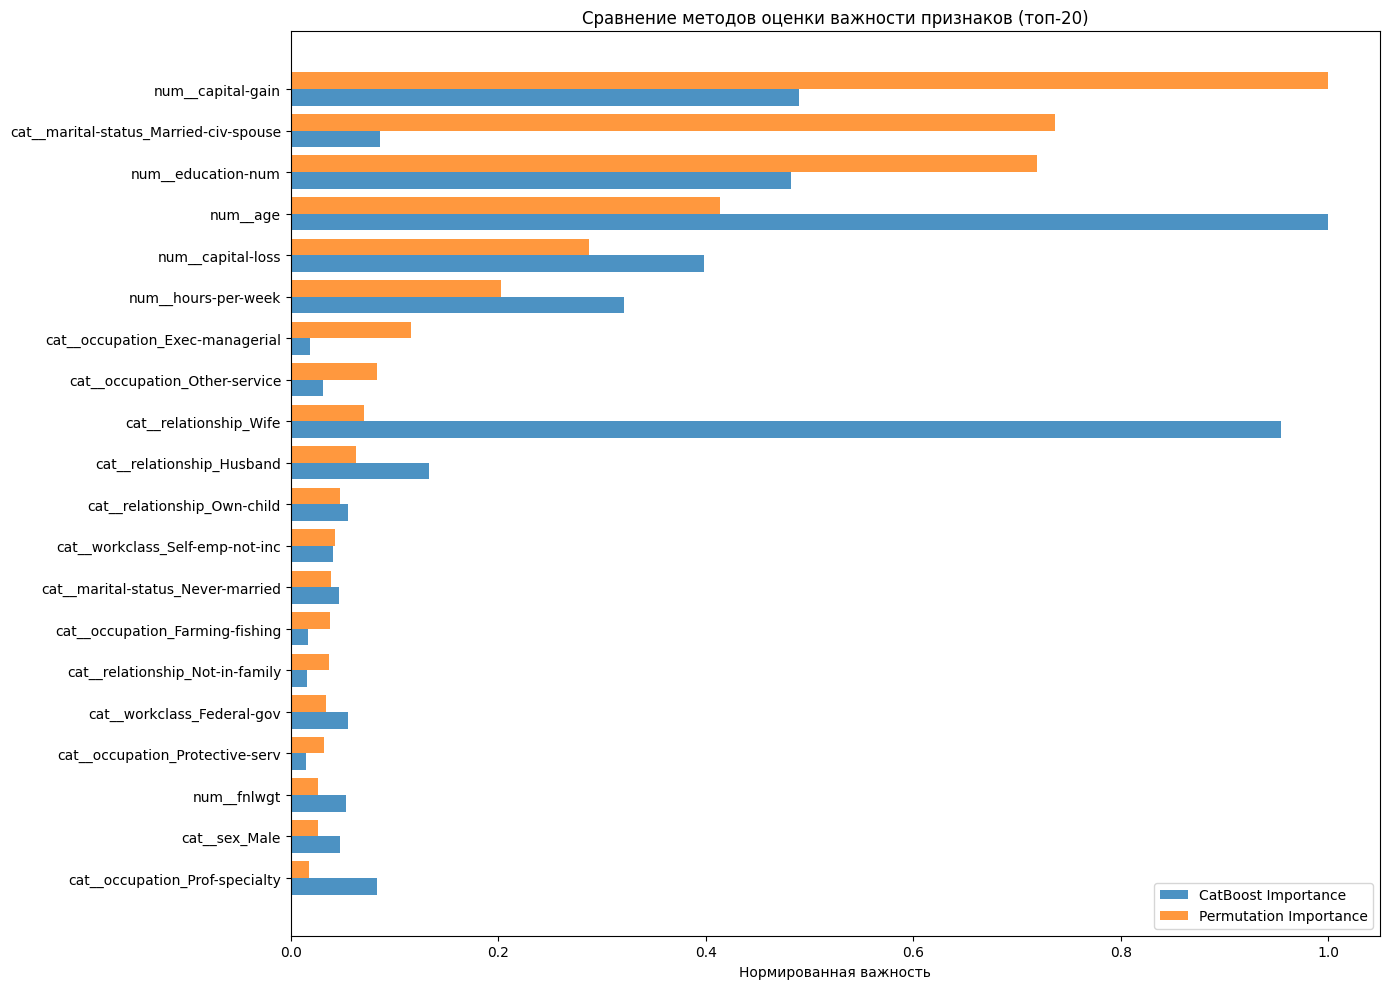


Выводы по permutation importance:
- Permutation importance показывает реальное влияние признаков на качество модели
- Нерелевантные признаки (random_feature1, random_feature2, random_feature3) имеют низкую важность
- Permutation importance более надежен для оценки реального вклада признаков по сравнению с встроенными методами


In [ ]:
from sklearn.inspection import permutation_importance

# Расчет permutation importance
start_time = time.time()
perm_importance = permutation_importance(
    final_model, 
    X_test_processed, 
    y_test, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='accuracy'
)
perm_time = time.time() - start_time

print(f"Время расчета permutation importance: {perm_time:.2f} секунд")

# Создание DataFrame с результатами
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nТоп-15 признаков по permutation importance:")
print(perm_df.head(15))

# Визуализация результатов
plt.figure(figsize=(14, 8))
plt.barh(perm_df['feature'][:15][::-1], perm_df['importance_mean'][:15][::-1], 
         xerr=perm_df['importance_std'][:15][::-1], capsize=5)
plt.title('Permutation Importance (топ-15 признаков)')
plt.xlabel('Снижение точности при перестановке признака')
plt.tight_layout()
plt.show()

# Сравнение с важностью от CatBoost
plt.figure(figsize=(12, 10))

# Берем топ-20 признаков по одному из методов
top20_features = perm_df.head(20)['feature'].values
catboost_importances = final_model.feature_importances_[np.isin(feature_names, top20_features)]
perm_importances = perm_df[perm_df['feature'].isin(top20_features)]['importance_mean'].values

# Сортируем по permutation importance
sort_idx = np.argsort(perm_importances)
top20_features_sorted = top20_features[sort_idx]
catboost_importances_sorted = catboost_importances[sort_idx]
perm_importances_sorted = perm_importances[sort_idx]

y = np.arange(len(top20_features_sorted))
height = 0.4

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(y - height/2, catboost_importances_sorted / catboost_importances_sorted.max(), 
        height=height, label='CatBoost Importance', alpha=0.8)
ax.barh(y + height/2, perm_importances_sorted / perm_importances_sorted.max(), 
        height=height, label='Permutation Importance', alpha=0.8)

ax.set_yticks(y)
ax.set_yticklabels(top20_features_sorted)
ax.set_xlabel('Нормированная важность')
ax.set_title('Сравнение методов оценки важности признаков (топ-20)')
ax.legend()
plt.tight_layout()
plt.show()

Время создания SHAP explainer: 0.05 секунд
Расчет SHAP-значений для 1000 объектов...
Время расчета SHAP-значений: 0.08 секунд
Форма SHAP-значений: (1000, 112)

Построение summary plot...


C:\Users\borga\AppData\Local\Temp\ipykernel_29512\914639460.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, X_test_sample, feature_names=feature_names, plot_type="bar", max_display=20)


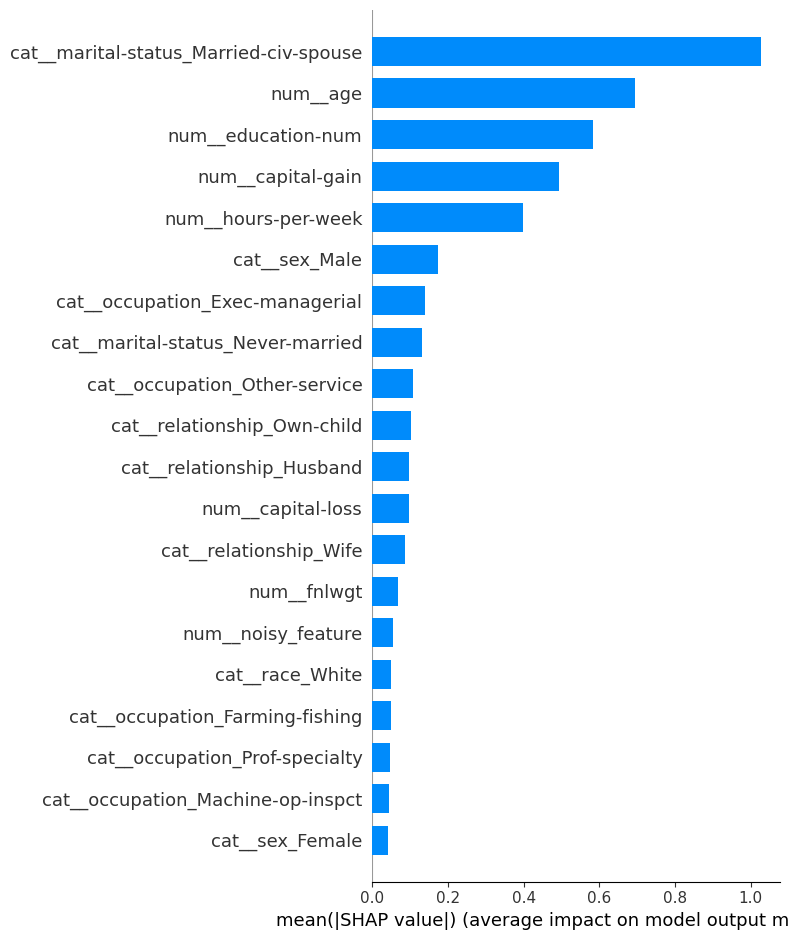

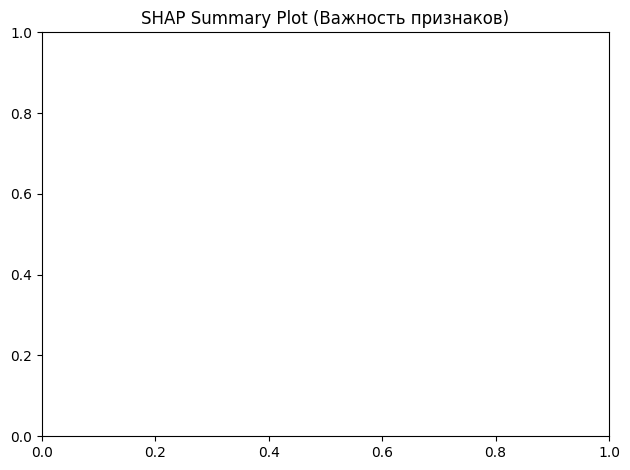

Построение beeswarm plot...


C:\Users\borga\AppData\Local\Temp\ipykernel_29512\914639460.py:42: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, X_test_sample, feature_names=feature_names, max_display=20)


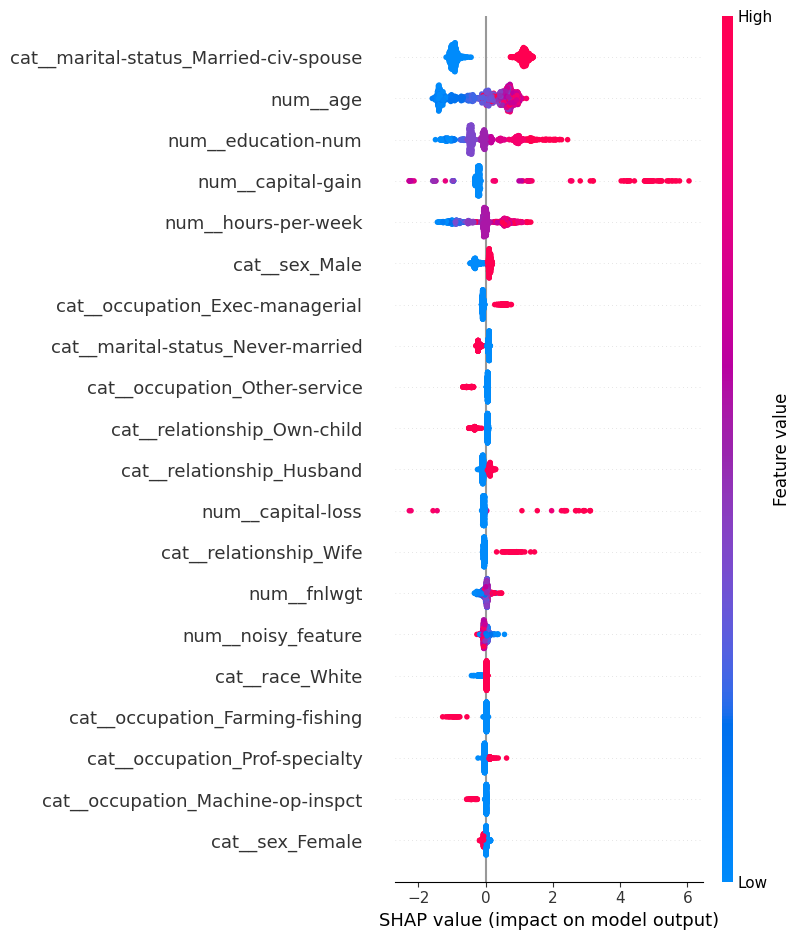

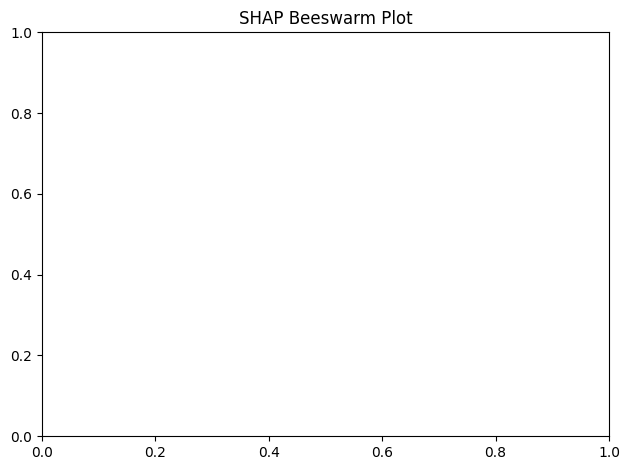

Построение dependence plots для топ-5 признаков: ['num__capital-gain', 'cat__marital-status_Married-civ-spouse', 'num__education-num', 'num__age', 'num__capital-loss']


<Figure size 1000x600 with 0 Axes>

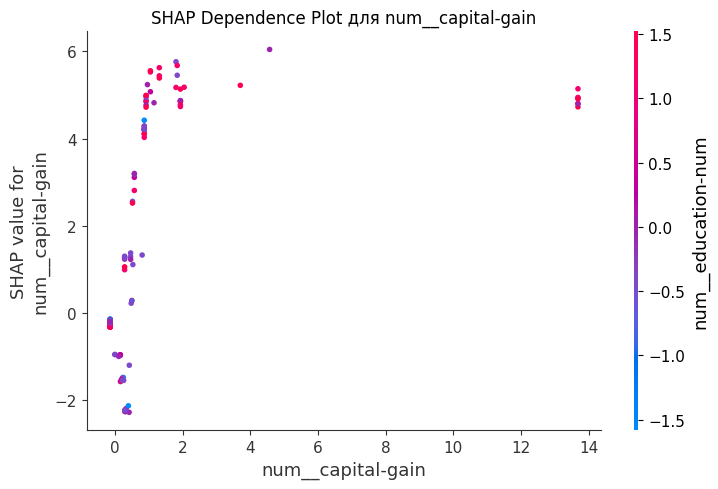

<Figure size 1000x600 with 0 Axes>

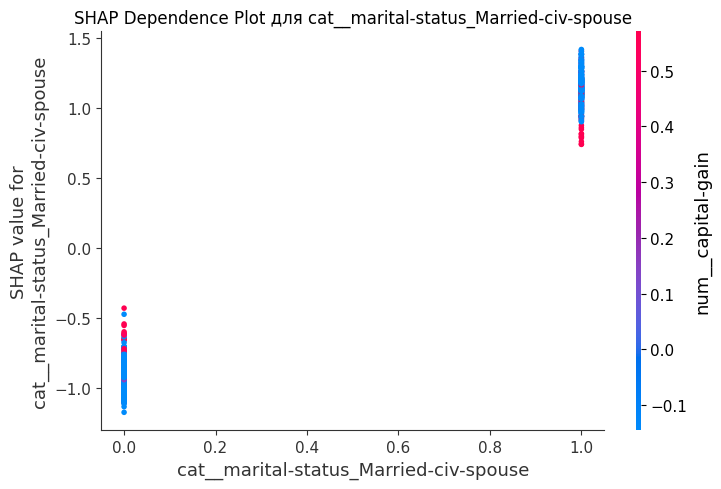

<Figure size 1000x600 with 0 Axes>

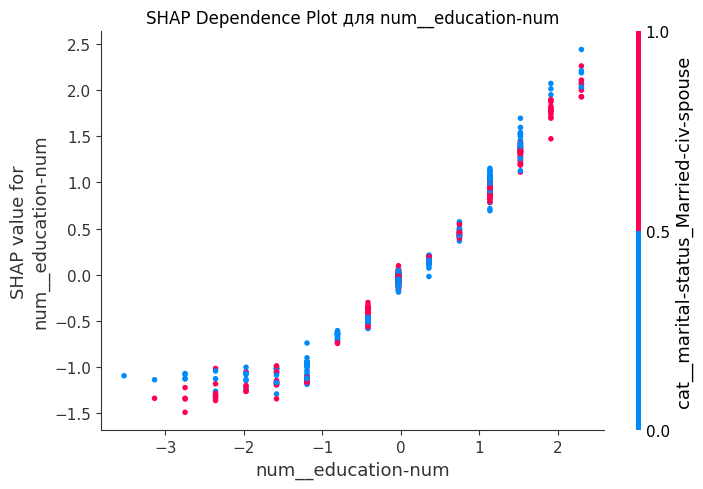

<Figure size 1000x600 with 0 Axes>

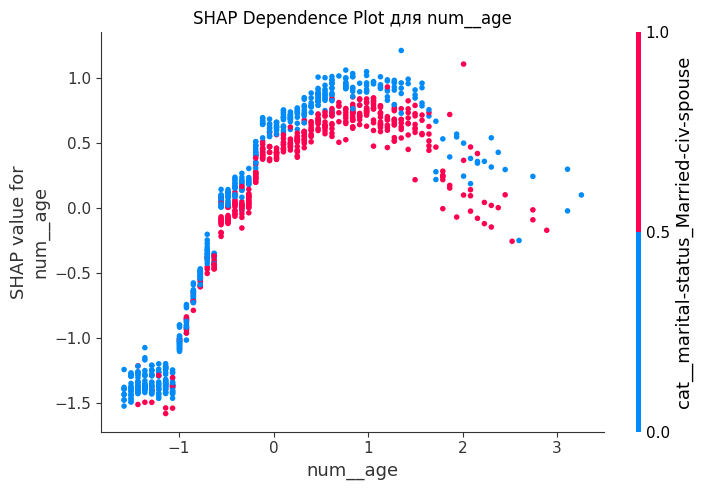

<Figure size 1000x600 with 0 Axes>

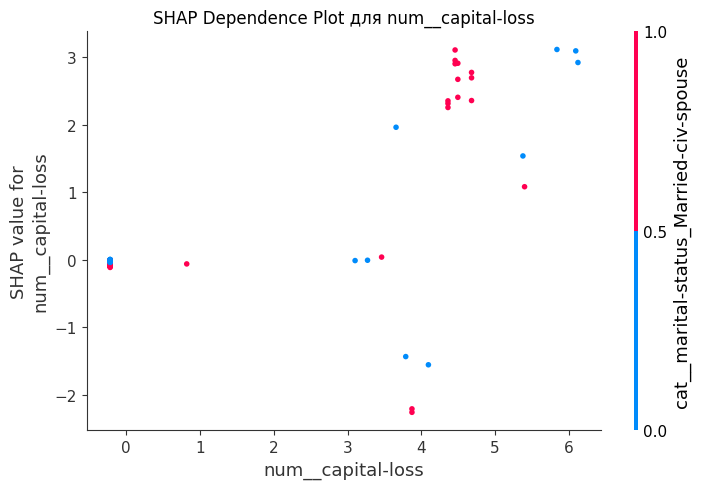


Построение force plot для конкретного примера...
Пример #0: Реальный класс - низкий доход (<=50K)
Предсказанная вероятность высокого дохода: 0.0088


<Figure size 2000x300 with 0 Axes>

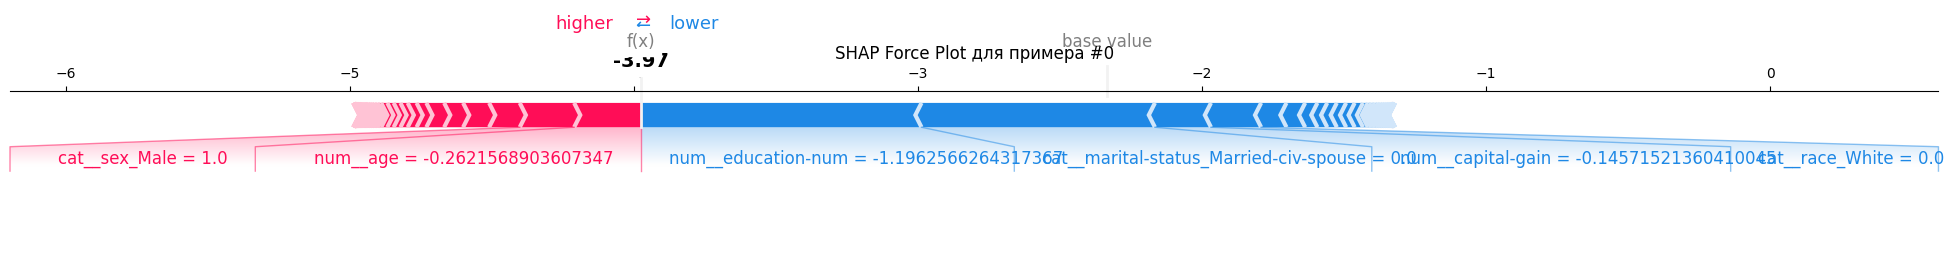

In [44]:
import shap

# Создание SHAP explainer
start_time = time.time()
explainer = shap.TreeExplainer(final_model)
shap_time = time.time() - start_time

print(f"Время создания SHAP explainer: {shap_time:.2f} секунд")

# Расчет SHAP-значений для подвыборки тестовых данных (для ускорения)
sample_size = 1000
if X_test_processed.shape[0] > sample_size:
    X_test_sample = shap.utils.sample(X_test_processed, sample_size, random_state=42)
else:
    X_test_sample = X_test_processed

print(f"Расчет SHAP-значений для {X_test_sample.shape[0]} объектов...")
start_time = time.time()
shap_values = explainer.shap_values(X_test_sample)
shap_calc_time = time.time() - start_time

print(f"Время расчета SHAP-значений: {shap_calc_time:.2f} секунд")

# Проверка размерности SHAP-значений
print(f"Форма SHAP-значений: {np.array(shap_values).shape}")

# Для бинарной классификации CatBoost возвращает SHAP-значения для каждого класса
# shap_values[1] соответствует положительному классу (>50K)
shap_values_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

# Summary plot (важность признаков)
print("\nПостроение summary plot...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_pos, X_test_sample, feature_names=feature_names, plot_type="bar", max_display=20)
plt.title('SHAP Summary Plot (Важность признаков)')
plt.tight_layout()
plt.show()

# Beeswarm plot (влияние значений признаков на предсказания)
print("Построение beeswarm plot...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_pos, X_test_sample, feature_names=feature_names, max_display=20)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.show()

# Dependence plots для топ-5 признаков
top5_features = perm_df.head(5)['feature'].values
print(f"Построение dependence plots для топ-5 признаков: {top5_features.tolist()}")

for feature in top5_features:
    try:
        feature_idx = np.where(feature_names == feature)[0][0]
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(feature_idx, shap_values_pos, X_test_sample, 
                            feature_names=feature_names, show=False)
        plt.title(f'SHAP Dependence Plot для {feature}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Ошибка при построении dependence plot для {feature}: {e}")

# Force plot для конкретного примера
print("\nПостроение force plot для конкретного примера...")
sample_idx = 0  # Индекс примера для визуализации

# Выбор интересного примера (с высокой вероятностью положительного класса)
if y_test[sample_idx] == 1:
    print(f"Пример #{sample_idx}: Реальный класс - высокий доход (>50K)")
else:
    print(f"Пример #{sample_idx}: Реальный класс - низкий доход (<=50K)")

print(f"Предсказанная вероятность высокого дохода: {final_model.predict_proba(X_test_processed[sample_idx].reshape(1, -1))[0, 1]:.4f}")

# Построение force plot
plt.figure(figsize=(20, 3))
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    shap_values_pos[sample_idx, :], 
    X_test_sample[sample_idx, :], 
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot для примера #{sample_idx}')
plt.tight_layout()
plt.show()

Сравнение SHAP и Permutation Importance...

Сравнение трех методов оценки важности (топ-15):
                                   feature  shap_importance  perm_importance  \
35  cat__marital-status_Married-civ-spouse         1.025905         0.036051   
0                                 num__age         0.693043         0.020236   
2                       num__education-num         0.582357         0.035191   
3                        num__capital-gain         0.494298         0.048948   
5                      num__hours-per-week         0.398563         0.009919   
66                           cat__sex_Male         0.174197         0.001259   
43         cat__occupation_Exec-managerial         0.138472         0.005681   
37       cat__marital-status_Never-married         0.132510         0.001873   
47           cat__occupation_Other-service         0.107163         0.004053   
57             cat__relationship_Own-child         0.102100         0.002334   
54               cat__relat

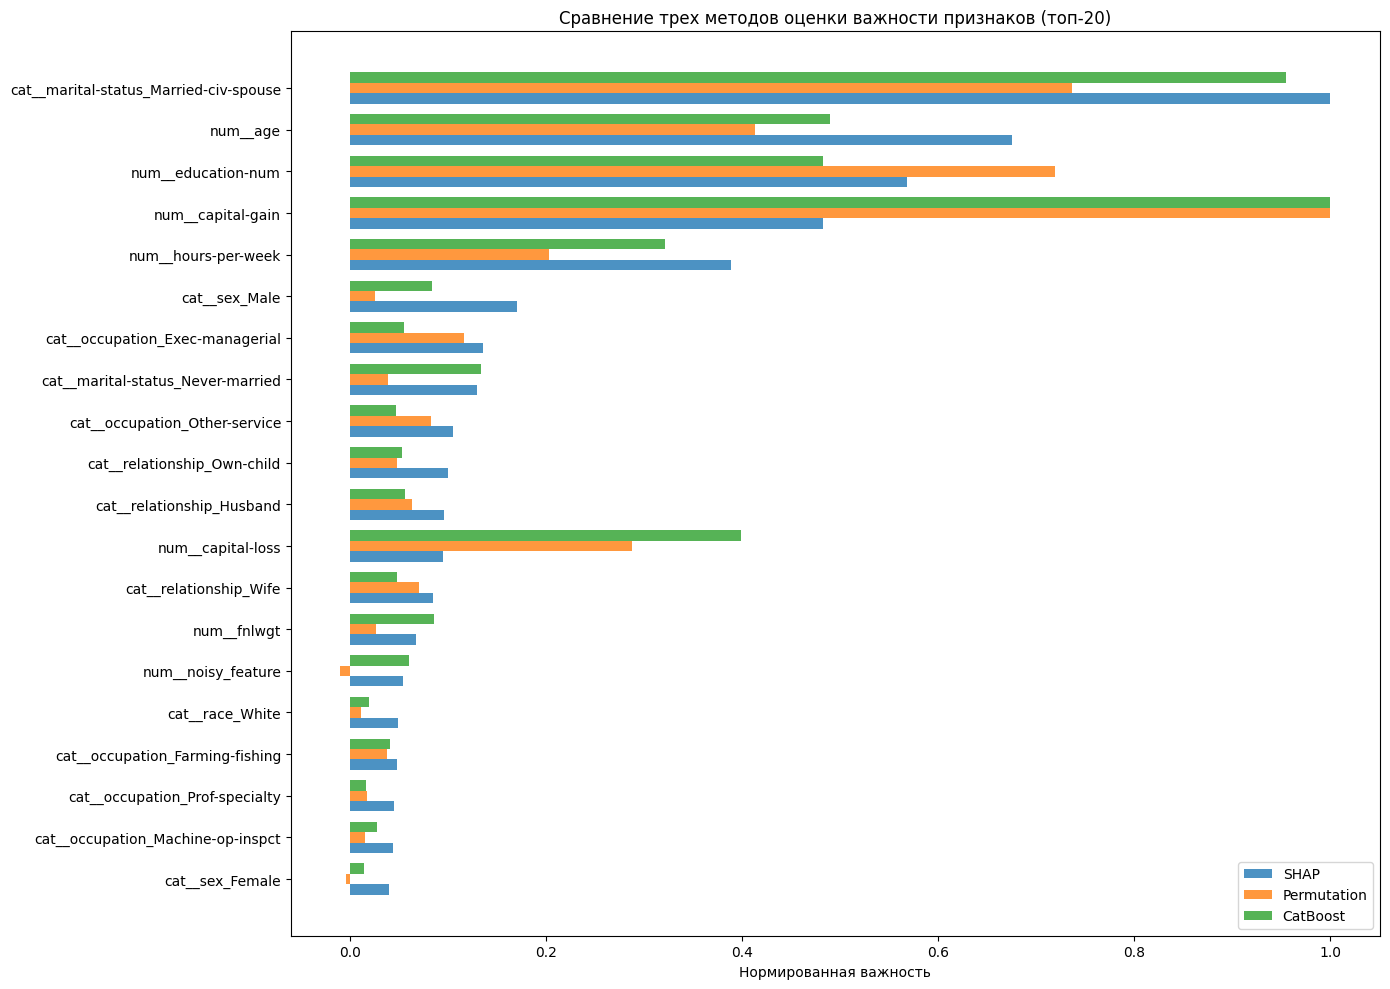


Удаление 5 наименее важных признаков по SHAP и переобучение модели...
Признаки для удаления: ['cat__native-country_Hungary', 'cat__native-country_Thailand', 'cat__native-country_Taiwan', 'cat__native-country_Scotland', 'cat__native-country_Portugal']

Результаты после удаления 5 наименее важных признаков:
Время обучения: 3.39 секунд (было 4.97 секунд)
Точность: 0.8767 (было 0.8772)
F1-мера: 0.7213 (была 0.7236)
AUC: 0.9296 (был 0.9286)

Кластеризация признаков по SHAP-значениям...


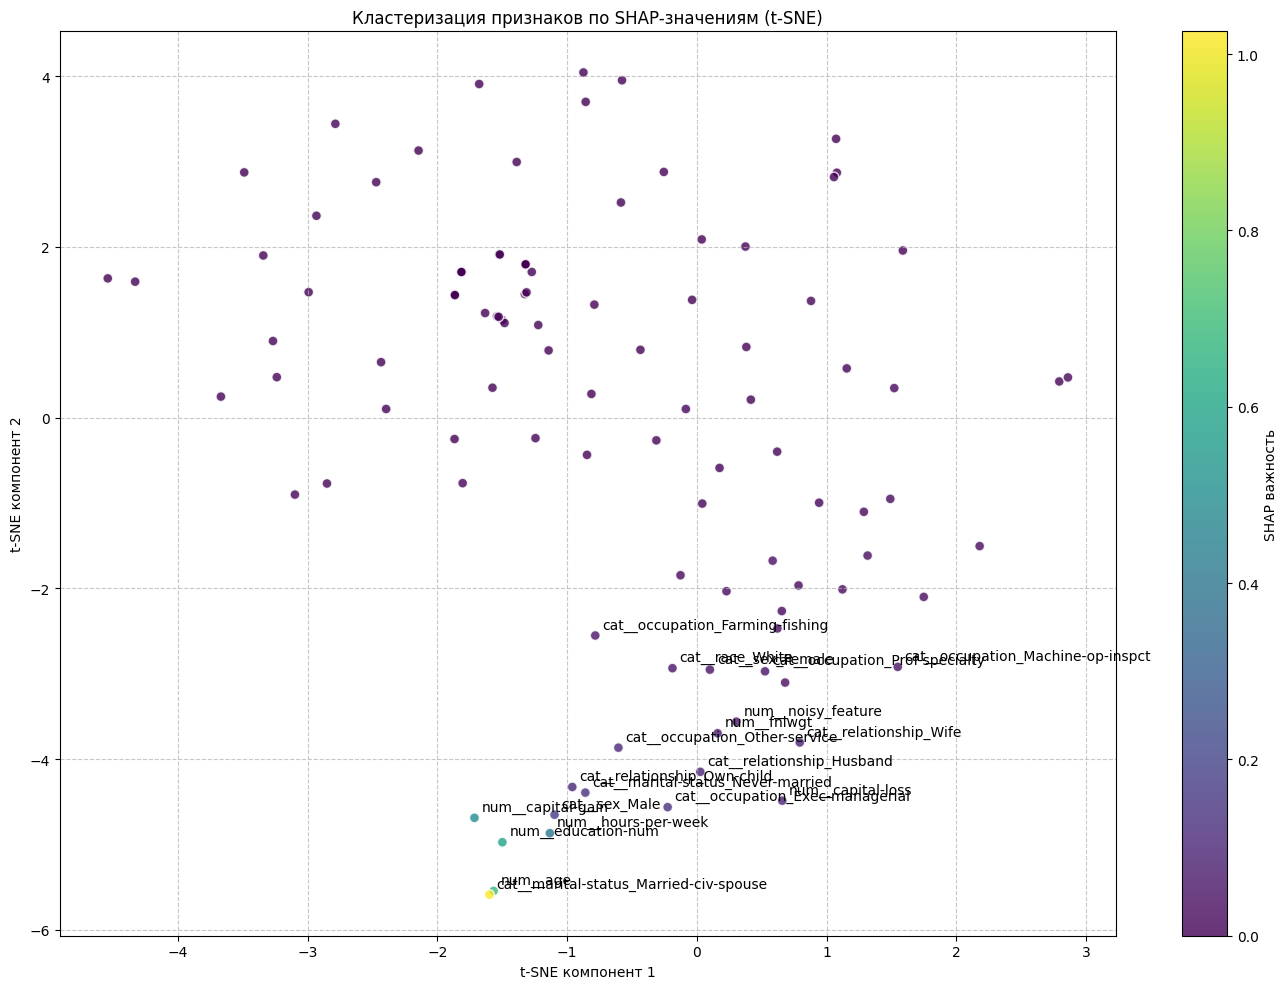


Ответы на вопросы:
1. Модельно-независимые методы отбора признаков:
   - Фильтрационные методы (корреляционный анализ, статистические тесты)
   - Некоторые варианты SHAP (KernelSHAP) могут быть модельно-независимыми
   Модельно-зависимые методы:
   - Оберточные методы (RFE)
   - Встроенные методы (feature importances, L1-регуляризация)
   - Permutation importance
   Причина: модельно-зависимые методы оценивают важность признаков через их влияние на конкретную модель.

2. SHAP считается устойчивым потому, что:
   - Основан на теории коалиционных игр (значения Шепли)
   - Удовлетворяет свойству согласованности (consistency)
   - Учитывает взаимодействие признаков
   - Даёт интерпретируемые результаты как для отдельных предсказаний, так и для всей модели

3. Если методы дают разные результаты:
   - Следует отдавать предпочтение методам, соответствующим цели задачи:
     * Для интерпретации - SHAP
     * Для оптимизации качества модели - permutation importance
     * Для скорости - встрое

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.manifold import TSNE


# Объединение результатов SHAP и Permutation Importance
# Для SHAP используем среднее абсолютное значение SHAP-значений
shap_importances = np.abs(shap_values_pos).mean(axis=0)

# Создание DataFrame для сравнения
comparison_df = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': shap_importances,
    'perm_importance': perm_df.set_index('feature').loc[feature_names, 'importance_mean'].values,
    'catboost_importance': final_model.feature_importances_
})

# Сортировка по SHAP-важности
comparison_df = comparison_df.sort_values('shap_importance', ascending=False)

print("\nСравнение трех методов оценки важности (топ-15):")
print(comparison_df.head(15))

# Нормализация для сравнения
comparison_df['shap_norm'] = comparison_df['shap_importance'] / comparison_df['shap_importance'].max()
comparison_df['perm_norm'] = comparison_df['perm_importance'] / comparison_df['perm_importance'].max()
comparison_df['catboost_norm'] = comparison_df['catboost_importance'] / comparison_df['catboost_importance'].max()

# Визуализация сравнения трех методов
plt.figure(figsize=(14, 10))
top20 = comparison_df.head(20)

y = np.arange(len(top20))
width = 0.25

plt.barh(y - width, top20['shap_norm'][::-1], height=width, label='SHAP', alpha=0.8)
plt.barh(y, top20['perm_norm'][::-1], height=width, label='Permutation', alpha=0.8)
plt.barh(y + width, top20['catboost_norm'][::-1], height=width, label='CatBoost', alpha=0.8)

plt.yticks(y, top20['feature'][::-1])
plt.xlabel('Нормированная важность')
plt.title('Сравнение трех методов оценки важности признаков (топ-20)')
plt.legend()
plt.tight_layout()
plt.show()

# Удаление 5 наименее важных признаков и переобучение модели
print("\nУдаление 5 наименее важных признаков по SHAP и переобучение модели...")

# Выбираем признаки для удаления (наименее важные по SHAP)
least_important_features = comparison_df.tail(5)['feature'].values
print(f"Признаки для удаления: {least_important_features.tolist()}")

# Создание новых наборов данных без этих признаков
features_to_keep = [f for f in feature_names if f not in least_important_features]
feature_indices_to_keep = [i for i, f in enumerate(feature_names) if f not in least_important_features]

X_train_reduced = X_train_processed[:, feature_indices_to_keep]
X_test_reduced = X_test_processed[:, feature_indices_to_keep]

# Обучение новой модели
reduced_model = CatBoostClassifier(**best_params)
start_time = time.time()
reduced_model.fit(X_train_reduced, y_train)
reduced_train_time = time.time() - start_time

# Оценка качества
y_pred_reduced = reduced_model.predict(X_test_reduced)
y_proba_reduced = reduced_model.predict_proba(X_test_reduced)[:, 1]

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
f1_reduced = f1_score(y_test, y_pred_reduced)
auc_reduced = roc_auc_score(y_test, y_proba_reduced)

print(f"\nРезультаты после удаления 5 наименее важных признаков:")
print(f"Время обучения: {reduced_train_time:.2f} секунд (было {train_time:.2f} секунд)")
print(f"Точность: {accuracy_reduced:.4f} (было {accuracy:.4f})")
print(f"F1-мера: {f1_reduced:.4f} (была {f1:.4f})")
print(f"AUC: {auc_reduced:.4f} (был {auc:.4f})")

# Кластеризация признаков по SHAP-значениям
print("\nКластеризация признаков по SHAP-значениям...")
# Используем матрицу SHAP-значений для кластеризации признаков
# Транспонируем матрицу для кластеризации признаков вместо объектов
shap_matrix = np.abs(shap_values_pos).T  # Форма: [n_features, n_samples]

# Применение t-SNE для визуализации кластеров признаков
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, shap_matrix.shape[0]-1))
shap_tsne = tsne.fit_transform(shap_matrix)

# Создание DataFrame для визуализации
tsne_df = pd.DataFrame({
    'tsne_x': shap_tsne[:, 0],
    'tsne_y': shap_tsne[:, 1],
    'feature': feature_names,
    'importance': shap_importances
})

# Визуализация кластеров признаков
plt.figure(figsize=(14, 10))
scatter = plt.scatter(tsne_df['tsne_x'], tsne_df['tsne_y'], 
                     c=tsne_df['importance'], s=50, alpha=0.8, 
                     cmap='viridis', edgecolors='w')

# Подписи для топ-20 признаков
top20_indices = np.argsort(shap_importances)[::-1][:20]
for idx in top20_indices:
    plt.annotate(feature_names[idx], 
                (shap_tsne[idx, 0], shap_tsne[idx, 1]),
                xytext=(5, 5), textcoords='offset points')

plt.colorbar(scatter, label='SHAP важность')
plt.title('Кластеризация признаков по SHAP-значениям (t-SNE)')
plt.xlabel('t-SNE компонент 1')
plt.ylabel('t-SNE компонент 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()